# Embedding Pipeline — Chapter 3 / Essay 1 (동적 그래프 임베딩 트랙)

병합 구성: `new-exp-001-data-processing` → `new-exp-001-lexical-model` → `new-exp-001-validation` → `downstream_analysis_v5`(centrality_patch 병합 버전)

- 4개 원본 노트북에서 완전히 동일한 셀(같은 Settings/imports/`scipy_to_graph_dict`)만 제거했고, 그 외 로직·그래프 디자인은 전부 그대로입니다.
- 각 Stage는 원래처럼 디스크에 저장된 중간 산출물(네트워크 npz, 임베딩 pt 등)을 읽고 쓰는 방식을 유지합니다 — 이어달리기식 재실행이 가능합니다.
- Stage 3(Validation)과 Stage 4(Downstream)는 각자 고유한 색상 팔레트(`#C0392B`/`#2471A3` vs `crimson`/`mediumblue`)를 그대로 씁니다. 서로 다른 걸 하나로 통일하면 기존 그래프 디자인이 바뀌므로 손대지 않았습니다.

# Stage 1 — Data & Network Construction

(`new-exp-001-data-processing.ipynb`)

In [ ]:
# !python -m pip install spacy
# !python -m pip install --upgrade --force-reinstall --no-cache-dir "numpy==2.0.2"
# !pip install tqdm_joblib
# !pip install spacy nltk
# !python -m spacy download en_core_web_sm

## Settings

In [1]:
import math
import pickle
import re
import sys
import logging
from collections import defaultdict, Counter
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import save_npz, load_npz, lil_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import spacy
import nltk
from nltk.stem import PorterStemmer


from tqdm.auto import tqdm
from joblib import Parallel, delayed

In [2]:
import os

# ── Paths ────────────────────────────────────────────────────────────────────
# BASE_DIR = 이 노트북이 있는 폴더. Jupyter를 다른 위치에서 실행 중이면
# 여기만 절대경로로 바꾸면 됩니다.
BASE_DIR = Path("..")   # notebooks/ 에서 실행 → 저장소 루트
# 원본 pkl이 외장하드 등 다른 곳에 있으면 SCISOC_RAW 환경변수로 지정.
DATA_DIR = Path(os.environ.get("SCISOC_RAW", BASE_DIR / "data" / "raw"))
NETWORKS_DIR = BASE_DIR / "data" / "processed" / "networks_emb"
LEXICAL_DIR  = BASE_DIR / "data" / "processed" / "lexical"
MODEL_DIR    = BASE_DIR / "models"
EMB_DIR      = BASE_DIR / "data" / "processed" / "embeddings"

for _dir in [LEXICAL_DIR, MODEL_DIR, NETWORKS_DIR, EMB_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

# ── Data sources ─────────────────────────────────────────────────────────────
SOURCES    = ["news", "paper"]
NEWS_PATH  = DATA_DIR / "news_subject_by_year.pkl"
PAPER_PATH = DATA_DIR / "paper_subject_by_year.pkl"

# ── Time range ───────────────────────────────────────────────────────────────
YEAR_START = 1990
YEAR_END   = 2023
YEARS      = list(range(YEAR_START, YEAR_END + 1))

In [3]:
print(DATA_DIR)
print(NETWORKS_DIR)
print(LEXICAL_DIR)
print(MODEL_DIR)
print(EMB_DIR)
print(YEARS[0], YEARS[-1], len(YEARS))


/root/data
/root/project/outputs/exp-new-001
/root/project/outputs/networks
1990 2023 34


## Data import 

In [4]:
# Data import 
news_df = pd.read_pickle(NEWS_PATH)
paper_df = pd.read_pickle(PAPER_PATH)

In [5]:
required_cols = {"id", "year", "subject"}

assert required_cols.issubset(news_df.columns), news_df.columns
assert required_cols.issubset(paper_df.columns), paper_df.columns

In [6]:
# 분석 기간만 사용
news_df  = news_df[(news_df["year"] >= YEAR_START) & (news_df["year"] <= YEAR_END)].copy()
paper_df = paper_df[(paper_df["year"] >= YEAR_START) & (paper_df["year"] <= YEAR_END)].copy()

# ── Lowercase 정규화 ──────────────────────────────────────────────────────────
# "Deep learning" / "deep learning" 같은 중복을 처음부터 제거
news_df["subject"]  = news_df["subject"].str.lower().str.strip()
paper_df["subject"] = paper_df["subject"].str.lower().str.strip()

print("news:",  news_df.shape,  news_df["year"].min(),  news_df["year"].max())
print("paper:", paper_df.shape, paper_df["year"].min(), paper_df["year"].max())

# 정규화 확인
print("\nnews subject sample:")
print(news_df["subject"].dropna().unique()[:10])
print("\npaper subject sample:")
print(paper_df["subject"].dropna().unique()[:10])


news: (4732500, 3) 1990 2023
paper: (73260868, 6) 1990 2023

news subject sample:
['fires' 'councils' 'workforce planning' 'automation' 'budgets'
 'call centers' 'automobile industry' 'crowdsourcing' 'automobile safety'
 'vehicles']

paper subject sample:
['boosting (machine learning)' 'electroencephalography'
 'pattern recognition (psychology)' 'wavelet' 'image (mathematics)'
 'field (mathematics)' 'objectivity (philosophy)'
 'artificial neural network' 'relevance (law)' 'support vector machine']


In [7]:
doc_subject_counts_news = news_df.groupby("id")["subject"].nunique()
doc_subject_counts_paper = paper_df.groupby("id")["subject"].nunique()

print(doc_subject_counts_news.describe())
print(doc_subject_counts_paper.describe())

count    722889.000000
mean          6.546648
std           3.773503
min           1.000000
25%           4.000000
50%           6.000000
75%           9.000000
max          37.000000
Name: subject, dtype: float64
count    1.328883e+07
mean     5.512942e+00
std      2.475981e+00
min      1.000000e+00
25%      4.000000e+00
50%      6.000000e+00
75%      7.000000e+00
max      2.000000e+01
Name: subject, dtype: float64


In [8]:
doc_counts = []

for source, df in [("news", news_df), ("paper", paper_df)]:
    tmp = (
        df.groupby("year")
        .agg(
            rows=("subject", "size"),
            docs=("id", "nunique"),
            subjects=("subject", "nunique"),
        )
        .reset_index()
    )
    tmp["source"] = source
    doc_counts.append(tmp)

doc_counts = pd.concat(doc_counts, ignore_index=True)
display(doc_counts.head())
display(doc_counts.tail())

display(doc_counts.pivot(index="year", columns="source", values="docs"))
display(doc_counts.pivot(index="year", columns="source", values="subjects"))

,year,rows,docs,subjects,source
0,1990,19414,2737,2440,news
1,1991,8290,1642,1674,news
2,1992,20952,3118,2403,news
3,1993,18026,2899,2446,news
4,1994,24750,3892,2651,news


,year,rows,docs,subjects,source
63,2019,4091137,740861,18075,paper
64,2020,4517802,803613,18254,paper
65,2021,4889677,845876,18133,paper
66,2022,4762563,819671,18098,paper
67,2023,5216958,928527,18168,paper


source,news,paper
year,,
1990,2737,77352
1991,1642,81844
1992,3118,88870
1993,2899,93556
1994,3892,98664
1995,3370,102530
1996,2632,111007
1997,2881,115358
1998,16217,122727


source,news,paper
year,,
1990,2440,12613
1991,1674,12678
1992,2403,13002
1993,2446,13102
1994,2651,13220
1995,2666,13643
1996,2666,13791
1997,2792,14003
1998,4402,14091


In [9]:
for source, df in [("news", news_df), ("paper", paper_df)]:
    doc_subject_counts = df.groupby("id")["subject"].nunique()
    print("\n", source)
    print(doc_subject_counts.describe())
    print("share docs with >=2 subjects:", (doc_subject_counts >= 2).mean())


 news
count    722889.000000
mean          6.546648
std           3.773503
min           1.000000
25%           4.000000
50%           6.000000
75%           9.000000
max          37.000000
Name: subject, dtype: float64
share docs with >=2 subjects: 0.9648286251416193

 paper
count    1.328883e+07
mean     5.512942e+00
std      2.475981e+00
min      1.000000e+00
25%      4.000000e+00
50%      6.000000e+00
75%      7.000000e+00
max      2.000000e+01
Name: subject, dtype: float64
share docs with >=2 subjects: 0.9490470606481488


## Global vocabulary 

In [10]:
all_subjects = pd.concat([
    news_df["subject"].dropna(),
    paper_df["subject"].dropna()
])

global_subjects = sorted(all_subjects.unique().tolist())
global_subj_idx = {s: i for i, s in enumerate(global_subjects)}

N = len(global_subjects)

print("Global vocabulary size:", N)
print(global_subjects[:20])

with open(NETWORKS_DIR / "global_subjects.pkl", "wb") as f:
    pickle.dump(global_subjects, f)

with open(NETWORKS_DIR / "global_subj_idx.pkl", "wb") as f:
    pickle.dump(global_subj_idx, f)

Global vocabulary size: 34403
['.net framework', '1,2,3-triazole', '1,2,4-triazole', '1,3,5-triazine', '1,4-dioxane', '1,4-naphthoquinone', '1-naphthol', '1-propanol', '11th century', '12th century', '14th century', '15th century', '16-bit', '16th century', '17th century', '18th century', '19th century', '2,4-dichlorophenoxyacetic acid', '2,4-dinitrophenol', '2-aminopyridine']


In [11]:
vocab_summary = pd.DataFrame([{
    "year_start": YEAR_START,
    "year_end": YEAR_END,
    "num_years": len(YEARS),
    "num_global_subjects": len(global_subjects),
    "num_news_rows": len(news_df),
    "num_paper_rows": len(paper_df),
    "num_news_docs": news_df["id"].nunique(),
    "num_paper_docs": paper_df["id"].nunique(),
    "num_news_subjects": news_df["subject"].nunique(),
    "num_paper_subjects": paper_df["subject"].nunique(),
}])

vocab_summary.to_csv(NETWORKS_DIR / "vocab_summary.csv",index=False)

display(vocab_summary)

,year_start,year_end,num_years,num_global_subjects,num_news_rows,num_paper_rows,num_news_docs,num_paper_docs,num_news_subjects,num_paper_subjects
0,1990,2023,34,34403,4732500,73260868,722889,13288831,15472,21174


## Network construction

### Functions

In [12]:
def build_network_fixed_vocab(grouped_docs, global_subj_idx):
    """
    document subject list -> fixed-vocabulary co-occurrence adjacency

    Parameters
    ----------
    grouped_docs:
        df.groupby("id")["subject"].apply(list)

    global_subj_idx:
        global subject -> index dict.

    Returns
    -------
    scipy.sparse.csr_matrix
        shape = [N, N]
    """
    n = len(global_subj_idx)
    matrix = lil_matrix((n, n), dtype=np.float32)

    for doc_subjects in grouped_docs:
        unique_subjects = list(set(doc_subjects))
        unique_subjects = [s for s in unique_subjects if s in global_subj_idx]

        d = len(unique_subjects)
        if d < 2:
            continue

        # 기존 방식 유지: 문서 내 subject 수가 많을수록 edge weight 폭증을 완화
        w = 1.0 / (d - 1)

        idx = [global_subj_idx[s] for s in unique_subjects]

        for i, j in combinations(idx, 2):
            matrix[i, j] += w
            matrix[j, i] += w

    csr = matrix.tocsr()
    csr.setdiag(0)
    csr.eliminate_zeros()

    return csr


def build_and_save_one_year(df, source, year, global_subj_idx, output_dir):
    df_y = df[df["year"] == year]

    if df_y.empty:
        adj = lil_matrix(
            (len(global_subj_idx), len(global_subj_idx)),
            dtype=np.float32
        ).tocsr()

        docs = 0
        unique_subjects = 0
        docs_with_ge2_subjects = 0
        share_docs_with_ge2_subjects = 0.0

    else:
        grouped_docs = df_y.groupby("id")["subject"].apply(list)

        doc_subject_counts = grouped_docs.apply(lambda x: len(set(x)))
        docs = len(grouped_docs)
        unique_subjects = df_y["subject"].nunique()
        docs_with_ge2_subjects = int((doc_subject_counts >= 2).sum())
        share_docs_with_ge2_subjects = float((doc_subject_counts >= 2).mean())

        adj = build_network_fixed_vocab(grouped_docs, global_subj_idx)

    save_path = output_dir / f"{source}_{year}_adj.npz"
    save_npz(save_path, adj)

    n = len(global_subj_idx)
    possible_directed_edges = n * (n - 1)

    nnz = adj.nnz
    unique_edges = nnz // 2
    density = nnz / possible_directed_edges if possible_directed_edges > 0 else 0.0

    if nnz > 0:
        mean_edge_weight = float(adj.data.mean())
        max_edge_weight = float(adj.data.max())
    else:
        mean_edge_weight = 0.0
        max_edge_weight = 0.0

    return {
        "source": source,
        "year": year,
        "rows": int(len(df_y)),
        "docs": int(docs),
        "unique_subjects": int(unique_subjects),
        "docs_with_ge2_subjects": int(docs_with_ge2_subjects),
        "share_docs_with_ge2_subjects": float(share_docs_with_ge2_subjects),
        "nnz": int(nnz),
        "unique_edges": int(unique_edges),
        "density": float(density),
        "total_weight": float(adj.sum()),
        "mean_edge_weight": mean_edge_weight,
        "max_edge_weight": max_edge_weight,
        "path": str(save_path),
    }
    

def build_and_save_all_years(df, source, years, global_subj_idx, output_dir, n_jobs=4):
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(build_and_save_one_year)(
            df=df,
            source=source,
            year=year,
            global_subj_idx=global_subj_idx,
            output_dir=output_dir,
        )
        for year in years
    )

    return pd.DataFrame(results)

### Test, 2020 only

In [13]:
test_source = "news"
test_year = 2020

df = news_df if test_source == "news" else paper_df
df_y = df[df["year"] == test_year]

grouped_docs = df_y.groupby("id")["subject"].apply(list)

print("rows:", len(df_y))
print("docs:", df_y["id"].nunique())
print("grouped docs:", len(grouped_docs))

adj_test = build_network_fixed_vocab(grouped_docs, global_subj_idx)

print("shape:", adj_test.shape)
print("nnz:", adj_test.nnz)
print("total weight:", float(adj_test.sum()))
print("density:", adj_test.nnz / (adj_test.shape[0] * adj_test.shape[1]))

rows: 292530
docs: 44032
grouped docs: 44032
shape: (34403, 34403)
nnz: 657968
total weight: 291235.96875
density: 0.0005559197988357238


In [14]:
test_source = "paper"
test_year = 2020

df = news_df if test_source == "news" else paper_df
df_y = df[df["year"] == test_year]

grouped_docs = df_y.groupby("id")["subject"].apply(list)

print("rows:", len(df_y))
print("docs:", df_y["id"].nunique())
print("grouped docs:", len(grouped_docs))

adj_test = build_network_fixed_vocab(grouped_docs, global_subj_idx)

print("shape:", adj_test.shape)
print("nnz:", adj_test.nnz)
print("total weight:", float(adj_test.sum()))
print("density:", adj_test.nnz / (adj_test.shape[0] * adj_test.shape[1]))

rows: 4517802
docs: 803613
grouped docs: 803613
shape: (34403, 34403)
nnz: 3842776
total weight: 4479670.5
density: 0.0032467768354855365


### All years

In [15]:
news_graph_summary = build_and_save_all_years(
    df=news_df,
    source="news",
    years=YEARS,
    global_subj_idx=global_subj_idx,
    output_dir=NETWORKS_DIR,
    n_jobs=4,
)

display(news_graph_summary)
news_graph_summary.to_csv(NETWORKS_DIR / "news_graph_summary.csv", index=False)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   15.9s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   31.0s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:   46.8s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:  1.1min
[Parallel(n_jobs=4)]: Done  31 out of  34 | elapsed:  1.4min remaining:    8.2s
[Parallel(n_jobs=4)]: Done  34 out of  34 | elapsed:  1.7min finished


,source,year,rows,docs,unique_subjects,docs_with_ge2_subjects,share_docs_with_ge2_subjects,nnz,unique_edges,density,total_weight,mean_edge_weight,max_edge_weight,path
0,news,1990,19414,2737,2440,2618,0.956522,87702,43851,0.000074,19295.000000,0.220006,26.928318,/root/project/outputs/networks/news_1990_adj.npz
1,news,1991,8290,1642,1674,1554,0.946407,30676,15338,0.000026,8202.001953,0.267375,28.319786,/root/project/outputs/networks/news_1991_adj.npz
2,news,1992,20952,3118,2403,3002,0.962797,79122,39561,0.000067,20835.998047,0.263340,46.711567,/root/project/outputs/networks/news_1992_adj.npz
3,news,1993,18026,2899,2446,2789,0.962056,76248,38124,0.000064,17916.000000,0.234970,88.725029,/root/project/outputs/networks/news_1993_adj.npz
4,news,1994,24750,3892,2651,3748,0.963001,93742,46871,0.000079,24606.000000,0.262486,84.149971,/root/project/outputs/networks/news_1994_adj.npz
5,news,1995,20352,3370,2666,3244,0.962611,82574,41287,0.000070,20226.000000,0.244944,138.852768,/root/project/outputs/networks/news_1995_adj.npz
6,news,1996,16035,2632,2666,2539,0.964666,70386,35193,0.000059,15942.001953,0.226494,35.674438,/root/project/outputs/networks/news_1996_adj.npz
7,news,1997,19794,2881,2792,2787,0.967372,89920,44960,0.000076,19700.000000,0.219084,33.916664,/root/project/outputs/networks/news_1997_adj.npz
8,news,1998,106686,16217,4402,15793,0.973855,252648,126324,0.000213,106262.031250,0.420593,632.327576,/root/project/outputs/networks/news_1998_adj.npz
9,news,1999,120309,17687,4668,17262,0.975971,277858,138929,0.000235,119884.046875,0.431458,648.091858,/root/project/outputs/networks/news_1999_adj.npz


In [16]:
paper_graph_summary = build_and_save_all_years(
    df=paper_df,
    source="paper",
    years=YEARS,
    global_subj_idx=global_subj_idx,
    output_dir=NETWORKS_DIR,
    n_jobs=2,
)

display(paper_graph_summary)
paper_graph_summary.to_csv(NETWORKS_DIR / "paper_graph_summary.csv", index=False)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:  2.0min
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:  4.9min
[Parallel(n_jobs=2)]: Done   9 tasks      | elapsed: 10.3min
[Parallel(n_jobs=2)]: Done  14 tasks      | elapsed: 15.7min
[Parallel(n_jobs=2)]: Done  21 tasks      | elapsed: 24.2min
[Parallel(n_jobs=2)]: Done  28 tasks      | elapsed: 32.1min
[Parallel(n_jobs=2)]: Done  34 out of  34 | elapsed: 41.2min finished


,source,year,rows,docs,unique_subjects,docs_with_ge2_subjects,share_docs_with_ge2_subjects,nnz,unique_edges,density,total_weight,mean_edge_weight,max_edge_weight,path
0,paper,1990,382163,77352,12613,70795,0.915232,794478,397239,0.000671,3.756029e+05,0.472767,422.209717,/root/project/outputs/networks/paper_1990_adj.npz
1,paper,1991,411079,81844,12678,75322,0.920312,834932,417466,0.000705,4.045519e+05,0.484533,461.598724,/root/project/outputs/networks/paper_1991_adj.npz
2,paper,1992,449735,88870,13002,81979,0.922460,891628,445814,0.000753,4.428429e+05,0.496668,508.831696,/root/project/outputs/networks/paper_1992_adj.npz
3,paper,1993,470098,93556,13102,86133,0.920657,923918,461959,0.000781,4.626729e+05,0.500773,579.674316,/root/project/outputs/networks/paper_1993_adj.npz
4,paper,1994,498592,98664,13220,91244,0.924795,967050,483525,0.000817,4.911659e+05,0.507901,561.918640,/root/project/outputs/networks/paper_1994_adj.npz
5,paper,1995,520252,102530,13643,94842,0.925017,1006472,503236,0.000850,5.125600e+05,0.509264,629.392944,/root/project/outputs/networks/paper_1995_adj.npz
6,paper,1996,567840,111007,13791,102738,0.925509,1070184,535092,0.000904,5.595650e+05,0.522868,687.214050,/root/project/outputs/networks/paper_1996_adj.npz
7,paper,1997,589878,115358,14003,107028,0.927790,1097626,548813,0.000927,5.815420e+05,0.529818,800.211487,/root/project/outputs/networks/paper_1997_adj.npz
8,paper,1998,626244,122727,14091,113760,0.926935,1144734,572367,0.000967,6.172700e+05,0.539226,789.693542,/root/project/outputs/networks/paper_1998_adj.npz
9,paper,1999,688872,132744,14485,123468,0.930121,1233524,616762,0.001042,6.795921e+05,0.550936,902.721436,/root/project/outputs/networks/paper_1999_adj.npz


In [17]:
graph_summary_all = pd.concat(
    [news_graph_summary, paper_graph_summary],
    ignore_index=True
)

graph_summary_all.to_csv(
    NETWORKS_DIR / "graph_summary_all.csv",
    index=False
)

In [18]:
for source in SOURCES:
    for year in YEARS:
        path = NETWORKS_DIR / f"{source}_{year}_adj.npz"
        assert path.exists(), path

        adj = load_npz(path)
        assert adj.shape == (N, N), (source, year, adj.shape)

print("All adjacency files exist and have fixed shape:", (N, N))

All adjacency files exist and have fixed shape: (34403, 34403)


In [19]:
def check_symmetry(adj):
    diff = adj - adj.T
    return diff.nnz == 0

for source in SOURCES:
    failed = []
    for year in YEARS:
        adj = load_npz(NETWORKS_DIR / f"{source}_{year}_adj.npz")
        if not check_symmetry(adj):
            failed.append(year)

    print(source, "symmetry failed years:", failed)

news symmetry failed years: []
paper symmetry failed years: []


In [20]:
for source in SOURCES:
    failed = []
    for year in YEARS:
        adj = load_npz(NETWORKS_DIR / f"{source}_{year}_adj.npz")
        diag_sum = adj.diagonal().sum()
        if diag_sum != 0:
            failed.append((year, diag_sum))

    print(source, "self-loop failed years:", failed)

news self-loop failed years: []
paper self-loop failed years: []


source,news,paper
year,,
1990,87702,794478
1991,30676,834932
1992,79122,891628
1993,76248,923918
1994,93742,967050
1995,82574,1006472
1996,70386,1070184
1997,89920,1097626
1998,252648,1144734


<Axes: title={'center': 'Number of nonzero adjacency entries by year'}, xlabel='year'>

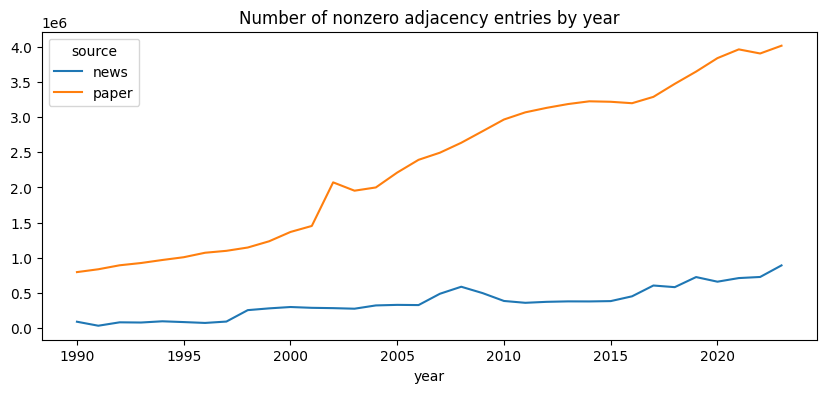

In [21]:
edge_pivot = graph_summary_all.pivot(index="year", columns="source", values="nnz")
display(edge_pivot)

edge_pivot.plot(figsize=(10, 4), title="Number of nonzero adjacency entries by year")

## Data transform

In [22]:
def scipy_to_graph_dict(adj, year):
    """
    scipy sparse adjacency -> plain PyTorch graph dict

    active_mask: [N] bool tensor
        해당 source-year에 degree > 0인 노드 True.
        temporal attention에서 inactive node를 masking하는 데 사용.
    """
    adj_coo = adj.tocoo()
    edge_index  = torch.tensor(np.vstack([adj_coo.row, adj_coo.col]), dtype=torch.long)
    edge_weight = torch.tensor(adj_coo.data, dtype=torch.float32)

    degree      = np.asarray(adj.sum(axis=1)).ravel()
    active_mask = torch.tensor(degree > 0, dtype=torch.bool)

    return {
        "edge_index":   edge_index,
        "edge_weight":  edge_weight,
        "active_mask":  active_mask,   # ← 추가
        "num_nodes":    adj.shape[0],
        "year":         year,
    }


def load_graph_sequence(networks_dir, source, years):
    graphs = []
    for year in years:
        adj_path = networks_dir / f"{source}_{year}_adj.npz"
        adj = sp.load_npz(adj_path)
        graphs.append(scipy_to_graph_dict(adj, year))
    return graphs

In [23]:
graphs_news = load_graph_sequence(
    networks_dir=NETWORKS_DIR,
    source="news",
    years=YEARS
)

len(graphs_news), graphs_news[0].keys()

(34,
 dict_keys(['edge_index', 'edge_weight', 'active_mask', 'num_nodes', 'year']))

In [24]:
graphs_paper = load_graph_sequence(
    networks_dir=NETWORKS_DIR,
    source="paper",
    years=YEARS
)

len(graphs_paper), graphs_paper[0].keys()

(34,
 dict_keys(['edge_index', 'edge_weight', 'active_mask', 'num_nodes', 'year']))

In [25]:
print("news:", len(graphs_news), graphs_news[0]["num_nodes"], graphs_news[0]["edge_index"].shape)
print("paper:", len(graphs_paper), graphs_paper[0]["num_nodes"], graphs_paper[0]["edge_index"].shape)

news: 34 34403 torch.Size([2, 87702])
paper: 34 34403 torch.Size([2, 794478])


## Lexical preprocessing

In [26]:
global_subjects = pd.read_pickle(NETWORKS_DIR / "global_subjects.pkl")
N = len(global_subjects)

In [27]:
# ── Vocabulary 필터링 ─────────────────────────────────────────────────────────
# 기준:
#   - source별로 등장 연도 수를 따로 계산
#   - 뉴스 OR 논문 중 하나에서 ≥3년 등장하면 포함
#   - lexical base 공유 비율이 높은 subject는 같은 계열로 간주 가능하도록
#     vocabulary를 넓게 유지
# 이전 ≥5년 기준에서 both=1이었으나 이 기준으로 변경

print("source별 active year 수 계산 중...")
news_active_count  = np.zeros(N, dtype=np.int32)
paper_active_count = np.zeros(N, dtype=np.int32)

for year in YEARS:
    adj = sp.load_npz(NETWORKS_DIR / f"news_{year}_adj.npz")
    news_active_count  += (np.asarray(adj.sum(axis=1)).ravel() > 0).astype(np.int32)

for year in YEARS:
    adj = sp.load_npz(NETWORKS_DIR / f"paper_{year}_adj.npz")
    paper_active_count += (np.asarray(adj.sum(axis=1)).ravel() > 0).astype(np.int32)

MIN_YEARS = 3   # 어느 한 source에서라도 3년 이상이면 포함
keep_mask = (news_active_count >= MIN_YEARS) | (paper_active_count >= MIN_YEARS)
keep_idx  = np.flatnonzero(keep_mask)
N_filtered = len(keep_idx)

# source별 membership 저장 (분석에서 그룹 구분용)
news_member  = news_active_count[keep_idx] >= MIN_YEARS
paper_member = paper_active_count[keep_idx] >= MIN_YEARS
both_member  = news_member & paper_member

global_subjects_filtered = [global_subjects[i] for i in keep_idx]
global_subj_idx_filtered = {s: i for i, s in enumerate(global_subjects_filtered)}
old_to_new = np.full(N, -1, dtype=np.int64)
old_to_new[keep_idx] = np.arange(N_filtered)

print(f"필터 전: {N}개")
print(f"필터 후: {N_filtered}개 ({N_filtered/N*100:.1f}%)")
print(f"  news-only:  {(news_member & ~paper_member).sum():,}")
print(f"  paper-only: {(paper_member & ~news_member).sum():,}")
print(f"  both:       {both_member.sum():,}")

# 저장
with open(NETWORKS_DIR / "global_subjects_filtered.pkl", "wb") as f:
    pickle.dump(global_subjects_filtered, f)
with open(NETWORKS_DIR / "global_subj_idx_filtered.pkl", "wb") as f:
    pickle.dump(global_subj_idx_filtered, f)
np.save(NETWORKS_DIR / "keep_idx.npy",        keep_idx)
np.save(NETWORKS_DIR / "old_to_new.npy",      old_to_new)
np.save(NETWORKS_DIR / "news_member.npy",     news_member)
np.save(NETWORKS_DIR / "paper_member.npy",    paper_member)
np.save(NETWORKS_DIR / "both_member.npy",     both_member)
print("저장 완료")


source별 active year 수 계산 중...
필터 전: 34403개
필터 후: 29312개 (85.2%)
  news-only:  8,727
  paper-only: 18,808
  both:       1,777
저장 완료


In [28]:
nlp = spacy.load("en_core_web_sm")
stemmer = PorterStemmer()

# spaCy가 stop word로 처리하지만 이 연구에선 의미 있는 토큰들
KEEP_TOKENS = {"ai", "ml", "nlp", "llm", "gpt", "rl"}

def phrase_to_bases(phrase: str) -> tuple[str, ...]:
    """
    subject phrase → lexical base tuple

    2단계 파이프라인:
      1. spaCy lemmatize : inflectional 변화 제거
         (algorithms → algorithm, running → run)
      2. Porter stem     : derivational 변화 제거
         (recommendation → recommend, fairness → fair)

    목적: raw surface 비교가 아닌 같은 lexical family 식별.
    attention candidate set 제공용이므로 약간의 over-grouping 허용.

    Examples:
        algorithmic bias         → ('algorithm', 'bias')
        recommendation systems   → ('recommend', 'system')
        algorithmic fairness     → ('algorithm', 'fair')
        AI regulation            → ('ai', 'regulat')
        deep learning models     → ('deep', 'learn', 'model')
    """
    text = str(phrase).lower()
    doc = nlp(text)
    bases = []
    for token in doc:
        if token.is_punct or not token.is_alpha:
            continue
        raw = token.text
        if raw in KEEP_TOKENS:
            bases.append(raw)
            continue
        if token.is_stop:
            continue
        lemma = token.lemma_
        stem = stemmer.stem(lemma)
        if len(stem) >= 3:
            bases.append(stem)
    return tuple(sorted(set(bases)))


def build_subject_lexical_resources(global_subjects, output_dir):
    print("Building lexical bases for", len(global_subjects), "subjects...")
    subject_bases = [phrase_to_bases(s) for s in tqdm(global_subjects)]

    base_vocab = sorted({b for bases in subject_bases for b in bases})
    base_idx   = {b: i for i, b in enumerate(base_vocab)}

    max_len  = max((len(b) for b in subject_bases), default=0)
    base_ids = np.full((len(global_subjects), max_len), -1, dtype=np.int64)
    base_mask = np.zeros((len(global_subjects), max_len), dtype=np.bool_)

    for i, bases in enumerate(subject_bases):
        for k, b in enumerate(bases):
            base_ids[i, k]  = base_idx[b]
            base_mask[i, k] = True

    # 저장
    with open(output_dir / "subject_bases.pkl", "wb") as f:
        pickle.dump(subject_bases, f)
    with open(output_dir / "base_vocab.pkl", "wb") as f:
        pickle.dump(base_vocab, f)
    with open(output_dir / "base_idx.pkl", "wb") as f:
        pickle.dump(base_idx, f)

    torch.save(torch.tensor(base_ids,  dtype=torch.long), output_dir / "subject_base_ids.pt")
    torch.save(torch.tensor(base_mask, dtype=torch.bool), output_dir / "subject_base_mask.pt")

    summary = pd.DataFrame({
        "subject":   global_subjects,
        "bases":     ["|".join(bases) for bases in subject_bases],
        "num_bases": [len(bases)      for bases in subject_bases],
    })
    summary.to_csv(output_dir / "subject_lexical_summary.csv", index=False)

    # 샘플 출력으로 결과 확인
    print(f"\nbase vocab size: {len(base_vocab)}")
    print(summary.sample(min(10, len(summary)))[["subject", "bases"]].to_string(index=False))

    return subject_bases, base_vocab, base_idx, base_ids, base_mask

subject_bases, base_vocab, base_idx, subject_base_ids, subject_base_mask = \
    build_subject_lexical_resources(global_subjects, LEXICAL_DIR)

Building lexical bases for 34403 subjects...


  0%|          | 0/34403 [00:00<?, ?it/s]


base vocab size: 15057
                          subject                 bases
                   head (geology)           geolog|head
                       hard metal            hard|metal
                       capitalism                 capit
company and organization profiles  compani|organ|profil
                     face surgery          face|surgeri
                caribbean studies       caribbean|studi
       platelet-activating factor activ|factor|platelet
                         arc lamp              arc|lamp
                             claw                  claw
                     turbo pascal          pascal|turbo


In [29]:
# ============================================================
# Source-year active lexical graph construction (filtered vocab)
# ============================================================

def active_nodes_from_adj(adj):
    degree = np.asarray(adj.sum(axis=1)).ravel()
    return np.flatnonzero(degree > 0)


def build_active_lexical_adj(active_nodes, subject_bases, n_nodes, dtype=np.float32):
    """
    필터된 vocab 기준 lexical adjacency.
    active_nodes: 해당 source-year에 degree>0인 노드 (filtered idx 기준)
    """
    base_to_nodes = defaultdict(list)
    active_set    = set(map(int, active_nodes))

    for i in active_set:
        for b in subject_bases[i]:
            base_to_nodes[b].append(i)

    pair_counts = defaultdict(float)
    for nodes in base_to_nodes.values():
        if len(nodes) < 2:
            continue
        nodes = sorted(nodes)
        for i, j in combinations(nodes, 2):
            pair_counts[(i, j)] += 1.0

    if not pair_counts:
        return sp.csr_matrix((n_nodes, n_nodes), dtype=dtype)

    rows, cols, data = [], [], []
    base_lens = np.array([max(len(bases), 1) for bases in subject_bases], dtype=np.float32)

    for (i, j), count in pair_counts.items():
        w = count / math.sqrt(float(base_lens[i] * base_lens[j]))
        rows.extend([i, j])
        cols.extend([j, i])
        data.extend([w, w])

    adj = sp.coo_matrix((np.array(data, dtype=dtype), (rows, cols)), shape=(n_nodes, n_nodes))
    adj = adj.tocsr()
    adj.setdiag(0)
    adj.eliminate_zeros()
    return adj


def build_and_save_lexical_graphs_filtered(
    networks_dir, lexical_dir, sources, years,
    subject_bases_filtered, N_filtered, old_to_new
):
    """
    필터된 vocab 기준으로 lexical graph 재구성.
    co-occurrence adj는 원래 N 크기이므로 old_to_new로 reindex.
    """
    summaries = []
    for source in sources:
        for year in years:
            # 원래 adj에서 active nodes 추출 후 filtered idx로 변환
            cooc_adj_orig = load_npz(networks_dir / f"{source}_{year}_adj.npz")
            active_orig   = active_nodes_from_adj(cooc_adj_orig)
            active_filt   = old_to_new[active_orig]
            active_filt   = active_filt[active_filt >= 0]   # 필터된 것만

            lex_adj = build_active_lexical_adj(
                active_filt, subject_bases_filtered, N_filtered
            )
            save_npz(lexical_dir / f"{source}_{year}_lex_adj_f.npz", lex_adj)

            summaries.append({
                "source":       source,
                "year":         year,
                "active_nodes": int(len(active_filt)),
                "lex_nnz":      int(lex_adj.nnz),
            })

    summary = pd.DataFrame(summaries)
    summary.to_csv(lexical_dir / "lexical_graph_summary_filtered.csv", index=False)
    return summary


# subject_bases를 필터된 vocab 기준으로 재구성
with open(LEXICAL_DIR / "subject_bases.pkl", "rb") as f:
    subject_bases_all = pickle.load(f)

subject_bases_filtered = [subject_bases_all[i] for i in keep_idx]

# co-occurrence adj도 filtered vocab 기준으로 재구성해서 저장
print("filtered co-occurrence adj 저장 중...")
for source in SOURCES:
    for year in tqdm(YEARS, desc=f"{source}"):
        cooc_orig = load_npz(NETWORKS_DIR / f"{source}_{year}_adj.npz")
        # old idx → new idx reindex
        cooc_orig = cooc_orig.tocoo()
        rows_new  = old_to_new[cooc_orig.row]
        cols_new  = old_to_new[cooc_orig.col]
        mask      = (rows_new >= 0) & (cols_new >= 0)
        cooc_filt = sp.coo_matrix(
            (cooc_orig.data[mask], (rows_new[mask], cols_new[mask])),
            shape=(N_filtered, N_filtered)
        ).tocsr()
        save_npz(NETWORKS_DIR / f"{source}_{year}_adj_f.npz", cooc_filt)

print("filtered lexical adj 저장 중...")
lex_summary = build_and_save_lexical_graphs_filtered(
    networks_dir=NETWORKS_DIR,
    lexical_dir=LEXICAL_DIR,
    sources=SOURCES,
    years=YEARS,
    subject_bases_filtered=subject_bases_filtered,
    N_filtered=N_filtered,
    old_to_new=old_to_new,
)
display(lex_summary.head())


filtered co-occurrence adj 저장 중...


news:   0%|          | 0/34 [00:00<?, ?it/s]

paper:   0%|          | 0/34 [00:00<?, ?it/s]

filtered lexical adj 저장 중...


,source,year,active_nodes,lex_nnz
0,news,1990,2262,37436
1,news,1991,1538,16502
2,news,1992,2307,37630
3,news,1993,2353,37682
4,news,1994,2537,44456


In [30]:
# # ============================================================
# # Load co-occurrence and lexical graph sequences
# # ============================================================

# def load_graph_sequence_from_pattern(directory, source, years, suffix):
#     graphs = []
#     for year in years:
#         adj = load_npz(directory / f"{source}_{year}_{suffix}.npz")
#         graphs.append(scipy_to_graph_dict(adj, year))
#     return graphs


# graphs_news_lex = load_graph_sequence_from_pattern(LEXICAL_DIR, "news", YEARS, "lex_adj")
# graphs_paper_lex = load_graph_sequence_from_pattern(LEXICAL_DIR, "paper", YEARS, "lex_adj")

# print("news cooc / lex:", len(graphs_news), len(graphs_news_lex), graphs_news_lex[0]["edge_index"].shape)
# print("paper cooc / lex:", len(graphs_paper), len(graphs_paper_lex), graphs_paper_lex[0]["edge_index"].shape)

# Stage 2 — Model Definition & Training (LexicalDySAT)

(`new-exp-001-lexical-model.ipynb`)

### Model
1. node_emb → [T, N, D]: timestep별 독립 초기 표현
2. position embedding 추가 (논문 Section 4.2)
3. inactive node masking: temporal attention에서 비활성 노드 제외
4. negative_sample: approximate (충돌 허용) → GPU 친화적

In [5]:
# ============================================================
# Lexical-neighbor DySAT — end-to-end, dim=32
# ============================================================

class SegmentSoftmaxGAT(nn.Module):
    def __init__(self, in_dim, out_dim, use_edge_weight=True, dropout=0.1):
        super().__init__()
        self.proj      = nn.Linear(in_dim, out_dim, bias=False)
        self.attn_src  = nn.Parameter(torch.empty(out_dim))
        self.attn_dst  = nn.Parameter(torch.empty(out_dim))
        self.edge_proj = nn.Linear(1, 1, bias=False) if use_edge_weight else None
        self.dropout   = nn.Dropout(dropout)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.proj.weight)
        nn.init.xavier_uniform_(self.attn_src.view(1, -1))
        nn.init.xavier_uniform_(self.attn_dst.view(1, -1))
        if self.edge_proj is not None:
            nn.init.xavier_uniform_(self.edge_proj.weight)

    def forward(self, x, edge_index, edge_weight=None):
        n        = x.size(0)
        src, dst = edge_index[0], edge_index[1]
        h        = self.proj(x)
        score    = (h[src] * self.attn_src).sum(-1) + (h[dst] * self.attn_dst).sum(-1)
        if self.edge_proj is not None and edge_weight is not None:
            score = score + self.edge_proj(torch.log1p(edge_weight).view(-1, 1)).view(-1)
        score = F.leaky_relu(score, negative_slope=0.2)

        max_per_dst = torch.full((n,), -torch.inf, device=x.device, dtype=score.dtype)
        max_per_dst.scatter_reduce_(0, dst, score, reduce="amax", include_self=True)
        exp_score = torch.exp(score - max_per_dst[dst])
        denom     = torch.zeros(n, device=x.device, dtype=score.dtype).scatter_add_(0, dst, exp_score)
        alpha     = exp_score / (denom[dst] + 1e-12)
        alpha     = self.dropout(alpha)

        out = torch.zeros(n, h.size(-1), device=x.device, dtype=h.dtype)
        out.index_add_(0, dst, h[src] * alpha.unsqueeze(-1))
        return out


class LexicalBagEncoder(nn.Module):
    def __init__(self, num_bases, base_dim, out_dim):
        super().__init__()
        self.base_emb = nn.Embedding(num_bases, base_dim)
        self.out      = nn.Linear(base_dim, out_dim)

    def forward(self, base_ids, base_mask):
        safe_ids = base_ids.clamp(min=0)
        emb      = self.base_emb(safe_ids) * base_mask.unsqueeze(-1).float()
        denom    = base_mask.sum(dim=1, keepdim=True).clamp(min=1).float()
        return self.out(emb.sum(dim=1) / denom)


class LexicalDySAT(nn.Module):
    """
    end-to-end LexicalDySAT.

    흐름:
      x = node_emb + lex_encoder(bases)         [N, D]
      각 timestep t:
        x\'_t = lex_attn(x, lex_graph_t)
        z_t   = cooc_attn(x\'_t, cooc_graph_t)  [N, H]
      temporal (node mini-batch):
        z_batch = z_seq[:, batch_idx, :]         [T, B, H]
        e_batch = temporal_attn(z_batch + pos)   [T, B, D]

    dropout: structural attention dropout (DySAT: 0.1)
    temporal_dropout: temporal attention dropout (DySAT: 0.5)
    """
    def __init__(
        self, num_nodes, num_timesteps, num_bases,
        base_ids, base_mask,
        input_dim=32, hidden_dim=32, out_dim=32,
        num_heads=4, dropout=0.1, temporal_dropout=0.5,
    ):
        super().__init__()
        self.num_nodes     = num_nodes
        self.num_timesteps = num_timesteps
        self.register_buffer("base_ids",  base_ids)
        self.register_buffer("base_mask", base_mask)

        self.node_emb      = nn.Embedding(num_nodes, input_dim)
        self.lex_encoder   = LexicalBagEncoder(num_bases, input_dim, input_dim)
        self.lex_attn      = SegmentSoftmaxGAT(input_dim,  hidden_dim, use_edge_weight=True, dropout=dropout)
        self.cooc_attn     = SegmentSoftmaxGAT(hidden_dim, hidden_dim, use_edge_weight=True, dropout=dropout)
        self.pos_emb       = nn.Embedding(num_timesteps, hidden_dim)
        self.temporal_attn = nn.MultiheadAttention(
            hidden_dim, num_heads, dropout=temporal_dropout, batch_first=True
        )
        self.out     = nn.Linear(hidden_dim, out_dim)
        self.dropout = nn.Dropout(dropout)

    def _node_features(self):
        ids = torch.arange(self.num_nodes, device=self.base_ids.device)
        return self.node_emb(ids) + self.lex_encoder(self.base_ids, self.base_mask)

    def structural_step(self, x, cooc_graph, lex_graph, max_edges=300000):
        ei_lex  = lex_graph["edge_index"]
        ew_lex  = lex_graph["edge_weight"]
        if ei_lex.size(1) > max_edges:
            perm   = torch.randperm(ei_lex.size(1), device=ei_lex.device)[:max_edges]
            ei_lex = ei_lex[:, perm]
            ew_lex = ew_lex[perm]

        ei_cooc = cooc_graph["edge_index"]
        ew_cooc = cooc_graph["edge_weight"]
        if ei_cooc.size(1) > max_edges:
            perm    = torch.randperm(ei_cooc.size(1), device=ei_cooc.device)[:max_edges]
            ei_cooc = ei_cooc[:, perm]
            ew_cooc = ew_cooc[perm]

        x_lex       = self.lex_attn(x, ei_lex, ew_lex)
        active_lex  = lex_graph["active_mask"]
        x_lex       = torch.where(active_lex.unsqueeze(-1), x_lex, x[:, :x_lex.size(-1)])
        z           = self.cooc_attn(x_lex, ei_cooc, ew_cooc)
        active_cooc = cooc_graph["active_mask"]
        z           = torch.where(active_cooc.unsqueeze(-1), z, x_lex)
        return self.dropout(z)

    def forward(self, cooc_graphs, lex_graphs, batch_size=512, return_attention=False):
        """Inference용: 전체 노드를 배치로 나눠서 처리."""
        T      = len(cooc_graphs)
        device = self.base_ids.device
        x      = self._node_features()

        z_list = []
        for cooc_graph, lex_graph in zip(cooc_graphs, lex_graphs):
            z_list.append(self.structural_step(x, cooc_graph, lex_graph))
        z_seq = torch.stack(z_list, dim=0)   # [T, N, H]
        del z_list

        pos         = self.pos_emb(torch.arange(T, device=device))
        causal_mask = torch.triu(torch.ones(T, T, device=device, dtype=torch.bool), diagonal=1)

        e_list, attn_list = [], []
        for start in range(0, self.num_nodes, batch_size):
            end     = min(start + batch_size, self.num_nodes)
            z_batch = z_seq[:, start:end, :]
            seq     = (z_batch + pos.unsqueeze(1)).permute(1, 0, 2)
            h, a    = self.temporal_attn(seq, seq, seq,
                                         attn_mask=causal_mask,
                                         need_weights=return_attention)
            e_list.append(self.out(h).permute(1, 0, 2))
            if return_attention:
                attn_list.append(a)

        e = torch.cat(e_list, dim=1)
        result = {"e": e}
        if return_attention:
            result["temporal_attention"] = torch.cat(attn_list, dim=0)
        return result


def move_graphs_to_device(graphs, device):
    return [{
        "edge_index":  g["edge_index"].to(device),
        "edge_weight": g["edge_weight"].to(device),
        "active_mask": g["active_mask"].to(device),
        "num_nodes":   g["num_nodes"],
        "year":        g["year"],
    } for g in graphs]


def approximate_negative_sample(num_nodes, num_neg, device):
    src = torch.randint(0, num_nodes, (num_neg * 2,), device=device)
    dst = torch.randint(0, num_nodes, (num_neg * 2,), device=device)
    mask = src != dst
    src, dst = src[mask][:num_neg], dst[mask][:num_neg]
    while src.size(0) < num_neg:
        s = torch.randint(0, num_nodes, (num_neg,), device=device)
        d = torch.randint(0, num_nodes, (num_neg,), device=device)
        m = s != d
        src = torch.cat([src, s[m]])[:num_neg]
        dst = torch.cat([dst, d[m]])[:num_neg]
    return torch.stack([src, dst], dim=0)


def edge_prediction_loss(emb_t, pos_edge_index, num_nodes, num_pos=50000, neg_ratio=1):
    device    = emb_t.device
    perm      = torch.randperm(pos_edge_index.size(1), device=device)[:min(num_pos, pos_edge_index.size(1))]
    pos_edges = pos_edge_index[:, perm]
    pos_score = (emb_t[pos_edges[0]] * emb_t[pos_edges[1]]).sum(-1)
    neg_edges = approximate_negative_sample(num_nodes, pos_edges.size(1) * neg_ratio, device)
    neg_score = (emb_t[neg_edges[0]] * emb_t[neg_edges[1]]).sum(-1)
    return (
        F.binary_cross_entropy_with_logits(pos_score, torch.ones_like(pos_score))
      + F.binary_cross_entropy_with_logits(neg_score, torch.zeros_like(neg_score))
    )


def train_one_source(
    model, networks_dir, lexical_dir, source, years,
    epochs=50, lr=1e-3, num_pos=50000, node_batch_size=512, device=None,
    patience=5, min_delta=1e-3,
):
    """
    end-to-end node mini-batch 학습.

    흐름 (배치당):
      x = _node_features()                          [N, D]
      연도별 structural_step → z_batch [T, B, H]    (batch_idx 노드만)
      temporal_attn → e_batch [T, B, D]
      loss.backward() → 전체 파라미터에 gradient

    Early stopping:
      patience epochs 연속으로 min_delta 이상 개선 없으면 종료
      best model 자동 복원
    """
    device    = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    T         = len(years)
    N         = model.num_nodes

    # ── adjacency list 사전 구성 ───────────────────────────────────────────────
    print("Building adjacency list...")
    year_adj = []
    for year in tqdm(years, desc="adj build"):
        cooc_adj = sp.load_npz(networks_dir / f"{source}_{year}_adj_f.npz")
        g        = scipy_to_graph_dict(cooc_adj, year)
        ei       = g["edge_index"]
        adj      = defaultdict(list)
        for s_, d_ in ei.t().tolist():
            adj[s_].append(d_)
            adj[d_].append(s_)
        year_adj.append(adj)
        del cooc_adj

    # ── early stopping 초기화 ──────────────────────────────────────────────────
    best_loss  = float('inf')
    best_epoch = 1
    no_improve = 0
    best_state = None

    history = []
    for epoch in range(1, epochs + 1):
        model.train()

        # 연도별 graph CPU 로드
        cooc_graphs_cpu, lex_graphs_cpu = [], []
        pbar = tqdm(years, total=T, desc=f"[{source}] epoch {epoch:02d} load")
        for year in pbar:
            cooc_adj = sp.load_npz(networks_dir / f"{source}_{year}_adj_f.npz")
            lex_adj  = sp.load_npz(lexical_dir  / f"{source}_{year}_lex_adj_f.npz")
            cooc_graphs_cpu.append(scipy_to_graph_dict(cooc_adj, year))
            lex_graphs_cpu.append(scipy_to_graph_dict(lex_adj,  year))
            del cooc_adj, lex_adj

        # node mini-batch
        node_perm  = torch.randperm(N)
        loss_total = 0.0
        n_batches  = math.ceil(N / node_batch_size)

        pbar = tqdm(range(0, N, node_batch_size), total=n_batches,
                    desc=f"[{source}] epoch {epoch:02d} train")
        for start in pbar:
            optimizer.zero_grad()
            end       = min(start + node_batch_size, N)
            batch_idx = node_perm[start:end]
            batch_set = set(batch_idx.tolist())
            B         = len(batch_idx)

            x = model._node_features()   # [N, D]

            z_batch_list = []
            for t in range(T):
                cooc_g = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                          for k, v in cooc_graphs_cpu[t].items()}
                lex_g  = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                          for k, v in lex_graphs_cpu[t].items()}
                z_t = model.structural_step(x, cooc_g, lex_g, max_edges=300000)
                z_batch_list.append(z_t[batch_idx.to(device)])
                del cooc_g, lex_g, z_t

            del x
            z_batch = torch.stack(z_batch_list, dim=0)   # [T, B, H]
            del z_batch_list

            pos         = model.pos_emb(torch.arange(T, device=device))
            causal_mask = torch.triu(torch.ones(T, T, device=device, dtype=torch.bool), diagonal=1)
            seq         = (z_batch + pos.unsqueeze(1)).permute(1, 0, 2)   # [B, T, H]
            h, _        = model.temporal_attn(seq, seq, seq,
                                              attn_mask=causal_mask,
                                              need_weights=False)
            e_batch = model.out(h).permute(1, 0, 2)   # [T, B, D]
            del z_batch, seq, h

            idx_map            = torch.full((N,), -1, dtype=torch.long)
            idx_map[batch_idx] = torch.arange(B)
            batch_loss         = torch.tensor(0.0, device=device)
            n_terms            = 0

            for t_idx in range(T):
                adj_ = year_adj[t_idx]
                src_list, dst_list = [], []
                for v in batch_set:
                    for u in adj_[v]:
                        if u in batch_set:
                            src_list.append(v)
                            dst_list.append(u)
                if not src_list:
                    continue
                ei_batch   = torch.tensor([src_list, dst_list], dtype=torch.long)
                ei_local   = idx_map[ei_batch].to(device)
                batch_loss = batch_loss + edge_prediction_loss(
                    e_batch[t_idx], ei_local, B, num_pos=num_pos
                )
                n_terms += 1

            del e_batch
            if n_terms > 0:
                (batch_loss / n_terms).backward()
                optimizer.step()
                loss_total += float(batch_loss.detach().cpu()) / n_terms

            torch.cuda.empty_cache()
            pbar.set_postfix(loss=f"{loss_total/max(start//node_batch_size+1,1):.4f}")

        del cooc_graphs_cpu, lex_graphs_cpu

        avg_loss = loss_total / n_batches
        history.append({"epoch": epoch, "loss": avg_loss})
        print(f"epoch={epoch:03d}  loss={avg_loss:.4f}")

        # ── Early stopping ─────────────────────────────────────────────────────
        if avg_loss < best_loss - min_delta:
            best_loss  = avg_loss
            best_epoch = epoch
            no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            print(f"  no improvement {no_improve}/{patience}  "
                  f"(best={best_loss:.4f} @ epoch {best_epoch})")
            if no_improve >= patience:
                print(f"Early stopping. Restoring best model from epoch {best_epoch}.")
                model.load_state_dict(best_state)
                break

    return model, pd.DataFrame(history)


In [6]:
import gc

keep_idx   = np.load(NETWORKS_DIR / "keep_idx.npy")
old_to_new = np.load(NETWORKS_DIR / "old_to_new.npy")
N_filtered = len(keep_idx)

with open(NETWORKS_DIR / "global_subjects_filtered.pkl", "rb") as f:
    global_subjects_filtered = pickle.load(f)

# source별 membership (분석 노트북에서 사용)
news_member  = np.load(NETWORKS_DIR / "news_member.npy")
paper_member = np.load(NETWORKS_DIR / "paper_member.npy")
both_member  = np.load(NETWORKS_DIR / "both_member.npy")

print(f"N_filtered: {N_filtered}")
print(f"  both:       {both_member.sum():,}")
print(f"  news-only:  {(news_member & ~paper_member).sum():,}")
print(f"  paper-only: {(paper_member & ~news_member).sum():,}")

device           = "cuda" if torch.cuda.is_available() else "cpu"
base_ids_tensor  = torch.load(LEXICAL_DIR / "subject_base_ids.pt")[keep_idx]
base_mask_tensor = torch.load(LEXICAL_DIR / "subject_base_mask.pt")[keep_idx]

with open(LEXICAL_DIR / "base_vocab.pkl", "rb") as f:
    base_vocab = pickle.load(f)

for _var in ["news_df", "paper_df", "graphs_news", "graphs_paper",
             "graphs_news_lex", "graphs_paper_lex"]:
    if _var in dir():
        exec(f"del {_var}")
gc.collect()
torch.cuda.empty_cache()
print(f"GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")


N_filtered: 29312
  both:       1,777
  news-only:  8,727
  paper-only: 18,808
GPU: 0.00 GB


### News

In [7]:
import torch
print(f"GPU 전체: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"GPU 사용중: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU 캐시: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

GPU 전체: 19.5 GB
GPU 사용중: 0.00 GB
GPU 캐시: 0.00 GB


In [8]:
model_news = LexicalDySAT(
    num_nodes        = N_filtered,
    num_timesteps    = len(YEARS),
    num_bases        = len(base_vocab),
    base_ids         = base_ids_tensor,
    base_mask        = base_mask_tensor,
    input_dim        = 32,
    hidden_dim       = 32,
    out_dim          = 32,
    num_heads        = 4,
    dropout          = 0.1,    # structural attention dropout (DySAT 공식)
    temporal_dropout = 0.5,    # temporal attention dropout  (DySAT 공식)
).to(device)

total = sum(p.numel() for p in model_news.parameters())
print(f"파라미터: {total:,}  ({total*4/1024**2:.1f} MB)")


파라미터: 1,429,410  (5.5 MB)


In [9]:
# ── news ──────────────────────────────────────────────────────────────────────
model_news, hist_news = train_one_source(
    model           = model_news,
    networks_dir    = NETWORKS_DIR,
    lexical_dir     = LEXICAL_DIR,
    source          = "news",
    years           = YEARS,
    epochs          = 50,
    lr              = 1e-3,
    num_pos         = 50000,
    node_batch_size = 512,
    device          = device,
    patience        = 5,
    min_delta       = 1e-3,
)
hist_news.to_csv(MODEL_DIR / "news_lexical_dysat_train_history.csv", index=False)
torch.save(model_news.state_dict(), MODEL_DIR / "news_lexical_dysat.pt")

# embedding 저장
model_news.eval()
_cooc = [scipy_to_graph_dict(sp.load_npz(NETWORKS_DIR / f"news_{y}_adj_f.npz"), y) for y in YEARS]
_lex  = [scipy_to_graph_dict(sp.load_npz(LEXICAL_DIR  / f"news_{y}_lex_adj_f.npz"), y) for y in YEARS]
with torch.no_grad():
    _out = model_news(
        move_graphs_to_device(_cooc, device),
        move_graphs_to_device(_lex,  device),
        batch_size=512,
        return_attention=True,
    )
torch.save(_out["e"].cpu(),                  EMB_DIR / "news_embeddings.pt")
torch.save(_out["temporal_attention"].cpu(), EMB_DIR / "news_temporal_attn.pt")
print("news embeddings saved:", _out["e"].shape)
del _cooc, _lex, _out
torch.cuda.empty_cache()


Building adjacency list...


adj build:   0%|          | 0/34 [00:00<?, ?it/s]

[news] epoch 01 load:   0%|          | 0/34 [00:00<?, ?it/s]

[news] epoch 01 train:   0%|          | 0/58 [00:00<?, ?it/s]

epoch=001  loss=1.0276


...

[news] epoch 33 train:   0%|          | 0/58 [00:00<?, ?it/s]

epoch=033  loss=0.7666
  no improvement 4/5  (best=0.7669 @ epoch 29)


[news] epoch 34 load:   0%|          | 0/34 [00:00<?, ?it/s]

[news] epoch 34 train:   0%|          | 0/58 [00:00<?, ?it/s]

epoch=034  loss=0.7680
  no improvement 5/5  (best=0.7669 @ epoch 29)
Early stopping. Restoring best model from epoch 29.
news embeddings saved: torch.Size([34, 29312, 32])


### Paper

In [10]:
# ── paper ─────────────────────────────────────────────────────────────────────
del model_news
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"GPU after clearing news model: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

GPU after clearing news model: 0.02 GB


In [11]:
model_paper = LexicalDySAT(
    num_nodes        = N_filtered,
    num_timesteps    = len(YEARS),
    num_bases        = len(base_vocab),
    base_ids         = base_ids_tensor,
    base_mask        = base_mask_tensor,
    input_dim        = 32,
    hidden_dim       = 32,
    out_dim          = 32,
    num_heads        = 4,
    dropout          = 0.1,
    temporal_dropout = 0.5,
).to(device)

model_paper, hist_paper = train_one_source(
    model           = model_paper,
    networks_dir    = NETWORKS_DIR,
    lexical_dir     = LEXICAL_DIR,
    source          = "paper",
    years           = YEARS,
    epochs          = 50,
    lr              = 1e-3,
    num_pos         = 50000,
    node_batch_size = 512,
    device          = device,
    patience        = 5,
    min_delta       = 1e-3,
)
hist_paper.to_csv(MODEL_DIR / "paper_lexical_dysat_train_history.csv", index=False)
torch.save(model_paper.state_dict(), MODEL_DIR / "paper_lexical_dysat.pt")

# embedding 저장
model_paper.eval()
_cooc = [scipy_to_graph_dict(sp.load_npz(NETWORKS_DIR / f"paper_{y}_adj_f.npz"), y) for y in YEARS]
_lex  = [scipy_to_graph_dict(sp.load_npz(LEXICAL_DIR  / f"paper_{y}_lex_adj_f.npz"), y) for y in YEARS]
with torch.no_grad():
    _out = model_paper(
        move_graphs_to_device(_cooc, device),
        move_graphs_to_device(_lex,  device),
        batch_size=512,
        return_attention=True,
    )
torch.save(_out["e"].cpu(),                  EMB_DIR / "paper_embeddings.pt")
torch.save(_out["temporal_attention"].cpu(), EMB_DIR / "paper_temporal_attn.pt")
print("paper embeddings saved:", _out["e"].shape)
del _cooc, _lex, _out
torch.cuda.empty_cache()


Building adjacency list...


adj build:   0%|          | 0/34 [00:00<?, ?it/s]

[paper] epoch 01 load:   0%|          | 0/34 [00:00<?, ?it/s]

[paper] epoch 01 train:   0%|          | 0/58 [00:00<?, ?it/s]

epoch=001  loss=1.0937


...

[paper] epoch 24 train:   0%|          | 0/58 [00:00<?, ?it/s]

epoch=024  loss=0.8913
  no improvement 4/5  (best=0.8895 @ epoch 20)


[paper] epoch 25 load:   0%|          | 0/34 [00:00<?, ?it/s]

[paper] epoch 25 train:   0%|          | 0/58 [00:00<?, ?it/s]

epoch=025  loss=0.8899
  no improvement 5/5  (best=0.8895 @ epoch 20)
Early stopping. Restoring best model from epoch 20.
paper embeddings saved: torch.Size([34, 29312, 32])


# Stage 3 — Downstream Analysis (drift · attention · case studies · element-level · PageRank)

(`downstream_analysis_v5.ipynb`, centrality_patch 이미 병합됨)

## 0. Setup

In [62]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
from sklearn.decomposition import PCA

# ── Paths ──────────────────────────────────────────────────
ANALYSIS_DIR = BASE_DIR / "results" / "figures" / "embedding_downstream"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# ── Time ───────────────────────────────────────────────────
T          = len(YEARS)

# ── Colors ─────────────────────────────────────────────────
NEWS_COLOR    = 'crimson'
PAPER_COLOR   = 'mediumblue'
SOURCE_COLORS = {'news': NEWS_COLOR, 'paper': PAPER_COLOR}

# ── Key Events ─────────────────────────────────────────────
KEY_EVENTS = {
    1995: 'SVM',
    1997: 'Deep Blue',
    2001: 'LIBSVM',
    2006: 'NVIDIA CUDA',
    2011: 'IBM Watson',
    2012: 'AlexNet',
    2014: 'GANs',
    2016: 'AlphaGo',
    2017: 'Transformer',
    2020: 'GPT-3/AlphaFold2',
    2022: 'ChatGPT',
}

def add_events(ax, ypos_frac=0.97, fontsize=7,
               color='#888888', lw=0.8):
    ylim = ax.get_ylim()
    ypos = ylim[0] + (ylim[1] - ylim[0]) * ypos_frac
    for yr, label in KEY_EVENTS.items():
        if YEAR_START <= yr <= YEAR_END:
            ax.axvline(yr, color=color, lw=lw,
                       ls='--', alpha=0.6, zorder=0)
            ax.text(yr + 0.15, ypos, label,
                    fontsize=fontsize, rotation=90,
                    va='top', color=color, alpha=0.8)

# ── Vocab ──────────────────────────────────────────────────
with open(NETWORKS_DIR / 'global_subjects_filtered.pkl', 'rb') as f:
    subjects = pickle.load(f)
subj_idx = {s: i for i, s in enumerate(subjects)}
N_FILT = len(subjects)
print(f'N_FILT={N_FILT:,}, T={T}')

N=29,312, T=34


### 0-1. Vocab Search

In [63]:
def search_subjects(query: str, top_k: int = 20) -> list:
    """
    Search vocab by partial string.
    Use this to find exact strings before setting CASE_SUBJECTS.
    
    Examples:
        search_subjects('artificial intelligence')
        search_subjects('deep learning')
        search_subjects('privacy')
    """
    hits = [s for s in subjects if query.lower() in s.lower()]
    print(f"'{query}' -> {len(hits)} matches \n(top {min(top_k, len(hits))}):")
    for s in hits[:top_k]:
        print(f'  [{subj_idx[s]:6d}] {s}')
    return hits


def get_idx(subject: str):
    """Exact match -> index. Prints candidates if not found."""
    if subject in subj_idx:
        return subj_idx[subject]
    candidates = [
        s for s in subjects
        if subject.lower() in s.lower()
    ][:5]
    if candidates:
        print(f"'{subject}' not found. Candidates: {candidates}")
    else:
        print(f"'{subject}' not found.")
    return None

# Quick check
for q in ['artificial intelligence', 'machine learning',
          'deep learning', 'neural network',
          'privacy', 'regulation', 'employment', 'algorithm']:
    _ = search_subjects(q, top_k=10)
    print()

'artificial intelligence' -> 11 matches 
(top 10):
  [   563] agents (artificial intelligence)
  [  1148] anticipation (artificial intelligence)
  [  1267] applications of artificial intelligence
  [  1472] artificial intelligence
  [  1473] artificial intelligence system
  [  1474] artificial intelligence, situated approach
  [  5743] conversational artificial intelligence
  [  8297] editorials -- artificial intelligence
  [ 11180] generative artificial intelligence
  [ 14456] knowledge bases (artificial intelligence)

'machine learning' -> 5 matches 
(top 5):
  [   291] active learning (machine learning)
  [  2892] boosting (machine learning)
  [ 15616] machine learning
  [ 15854] margin (machine learning)
  [ 23670] semantic analysis (machine learning)

'deep learning' -> 1 matches 
(top 1):
  [  6868] deep learning

'neural network' -> 6 matches 
(top 6):
  [  1479] artificial neural network
  [  1480] artificial neural networks
  [  2514] biological neural network
  [  5763] convo

In [64]:
# ── Case Study keywords ────────────────────────────────────
# Set after checking search results above.
CASE_SUBJECTS_RAW = [
    'Applications of artificial intelligence',
    'machine learning',
    'Deep learning',
    'artificial neural network',
    'data privacy',
    'algorithmic bias',
]
CASE_SUBJECTS = [
    s for s in CASE_SUBJECTS_RAW
    if get_idx(s) is not None
]
print(f'\nValid CASE_SUBJECTS ({len(CASE_SUBJECTS)}): '
      f'{CASE_SUBJECTS}')

'Applications of artificial intelligence' not found. Candidates: ['applications of artificial intelligence']
'Deep learning' not found. Candidates: ['deep learning']
'data privacy' not found.
'algorithmic bias' not found.

Valid CASE_SUBJECTS (2): ['machine learning', 'artificial neural network']


### 0-2. both_member

In [65]:
news_appeared  = np.zeros(N_FILT, dtype=bool)
paper_appeared = np.zeros(N_FILT, dtype=bool)

for yr in tqdm(YEARS, desc='membership'):
    adj_n = sp.load_npz(
        NETWORKS_DIR / f'news_{yr}_adj_f.npz')
    adj_p = sp.load_npz(
        NETWORKS_DIR / f'paper_{yr}_adj_f.npz')
    news_appeared  |= (
        np.asarray(adj_n.sum(axis=1)).ravel() > 0)
    paper_appeared |= (
        np.asarray(adj_p.sum(axis=1)).ravel() > 0)

both_member = news_appeared & paper_appeared
print(f'news:  {news_appeared.sum():,}')
print(f'paper: {paper_appeared.sum():,}')
print(f'both:  {both_member.sum():,}')

membership:   0%|          | 0/34 [00:00<?, ?it/s]

news:  10,965
paper: 20,587
both:  2,240


In [66]:
def search_subjects_cross_source(query: str, top_k: int = 30):
    """
    Search subjects by partial string and show whether each hit appears
    in news, paper, or both.
    """
    q = query.lower()

    hits = [s for s in subjects if q in s.lower()]
    news_hits = [s for s in hits if news_appeared[subj_idx[s]]]
    paper_hits = [s for s in hits if paper_appeared[subj_idx[s]]]
    both_hits = [s for s in hits if both_member[subj_idx[s]]]

    print(f"query: {query}")
    print(f"raw matches:   {len(hits):,}")
    print(f"news matches:  {len(news_hits):,}")
    print(f"paper matches: {len(paper_hits):,}")
    print(f"same-index both matches: {len(both_hits):,}")
    print()

    print(f"Top {min(top_k, len(hits))} raw hits:")
    for s in hits[:top_k]:
        idx = subj_idx[s]
        if both_member[idx]:
            status = "BOTH"
        elif news_appeared[idx]:
            status = "NEWS_ONLY"
        elif paper_appeared[idx]:
            status = "PAPER_ONLY"
        else:
            status = "NONE"

        print(f"[{idx:6d}] {status:10s} | {s}")

    return {
        "raw": hits,
        "news": news_hits,
        "paper": paper_hits,
        "both": both_hits,
    }

ai_hits = search_subjects_cross_source("processing")

query: processing
raw matches:   50
news matches:  28
paper matches: 30
same-index both matches: 8

Top 30 raw hits:
[  1513] PAPER_ONLY | aseptic processing
[  2167] BOTH       | batch processing
[  3902] PAPER_ONLY | central processing unit
[  3903] NEWS_ONLY  | central processing units--cpus
[  4048] NEWS_ONLY  | check processing
[  4449] NEWS_ONLY  | claims processing
[  5661] NEWS_ONLY  | continuous processing
[  6126] NEWS_ONLY  | credit card processing
[  6684] PAPER_ONLY | data pre-processing
[  6685] BOTH       | data processing
[  6686] NEWS_ONLY  | data processing (computers)
[  6687] PAPER_ONLY | data processing system
[  6869] PAPER_ONLY | deep linguistic processing
[  7414] PAPER_ONLY | digital signal processing
[  7694] NEWS_ONLY  | distributed processing
[  7789] PAPER_ONLY | document processing
[  7873] PAPER_ONLY | downstream processing
[  8522] NEWS_ONLY  | electronic claims processing
[  8530] PAPER_ONLY | electronic data processing
[  8829] PAPER_ONLY | energy (sig

## 1. Preprocessing

In [67]:
# ── 1-1. Unit norm ─────────────────────────────────────────
emb  = {}
attn = {}

for src in SOURCES:
    raw = torch.load(
        EMB_DIR / f'{src}_embeddings.pt',
        map_location='cpu')
    emb[src] = F.normalize(raw, p=2, dim=-1)  # [T, N_FILT, 32]
    attn[src] = torch.load(
        EMB_DIR / f'{src}_temporal_attn.pt',
        map_location='cpu')                    # [N_FILT, T, T]
    print(f'{src}: emb {tuple(emb[src].shape)}, '
          f'attn {tuple(attn[src].shape)}')

news: emb (34, 29312, 32), attn (29312, 34, 34)
paper: emb (34, 29312, 32), attn (29312, 34, 34)


In [68]:
# ── 1-2. L2 Drift ──────────────────────────────────────────
def compute_l2_drift(emb_norm: torch.Tensor) -> torch.Tensor:
    """[T, N, D] -> [T-1, N]"""
    return (emb_norm[1:] - emb_norm[:-1]).norm(dim=-1)

drift = {src: compute_l2_drift(emb[src]) for src in SOURCES}

for src in SOURCES:
    d = drift[src].numpy()
    print(f'{src}: median={np.median(d):.4f}, '
          f'p90={np.percentile(d, 90):.4f}')

news: median=0.0508, p90=0.2161
paper: median=0.0494, p90=0.4666


In [69]:
# ── 1-3. Co-occ degree ─────────────────────────────────────
def load_cooc_degree(source: str) -> np.ndarray:
    """[T, N]"""
    mat = np.zeros((T, N_FILT), dtype=np.float32)
    for t, yr in enumerate(
            tqdm(YEARS, desc=f'{source} cooc')):
        adj = sp.load_npz(
            NETWORKS_DIR / f'{source}_{yr}_adj_f.npz')
        mat[t] = np.asarray(adj.sum(axis=1)).ravel()
    return mat

cooc_degree = {
    src: load_cooc_degree(src) for src in SOURCES
}

news cooc:   0%|          | 0/34 [00:00<?, ?it/s]

paper cooc:   0%|          | 0/34 [00:00<?, ?it/s]

## 2. Global Drift 방향 변화량

In [70]:
for src in SOURCES:
    d = drift[src].numpy().ravel()
    d = d[~np.isnan(d)]
    print(f"{src}: mean={d.mean():.4f}, p50={np.median(d):.4f}, "
          f"p90={np.percentile(d,90):.4f}, p99={np.percentile(d,99):.4f}")

news: mean=0.1639, p50=0.0508, p90=0.2161, p99=1.9078
paper: mean=0.1727, p50=0.0494, p90=0.4666, p99=1.7101


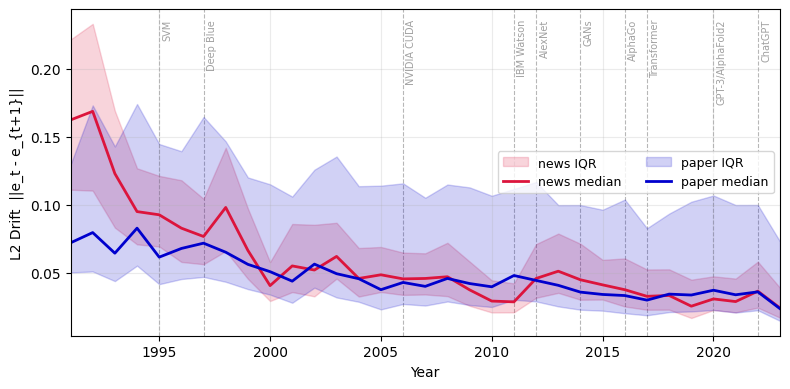

In [71]:
fig, ax = plt.subplots(figsize=(8, 4))

for src in SOURCES:
    d = drift[src].numpy()  # [T-1, N_FILT]
    color = SOURCE_COLORS[src]

    q25, q50, q75 = np.nanpercentile(d, [25, 50, 75], axis=1)

    ax.fill_between(YEARS[1:], q25, q75, color=color, alpha=0.18, label=f'{src} IQR')
    ax.plot(YEARS[1:], q50, color=color, lw=2, label=f'{src} median')

ax.set_xlim(YEAR_START+1, YEAR_END)
ax.set_xlabel('Year')
ax.set_ylabel('L2 Drift  ||e_t - e_{t+1}||')
# ax.set_title('Global Drift Velocity — Median and IQR', fontweight='bold')
ax.legend(ncol=2, fontsize=9, loc='center right')
ax.grid(alpha=0.25)
add_events(ax)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / '2-1_global_drift_median_iqr.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Temporal Attention Analysis

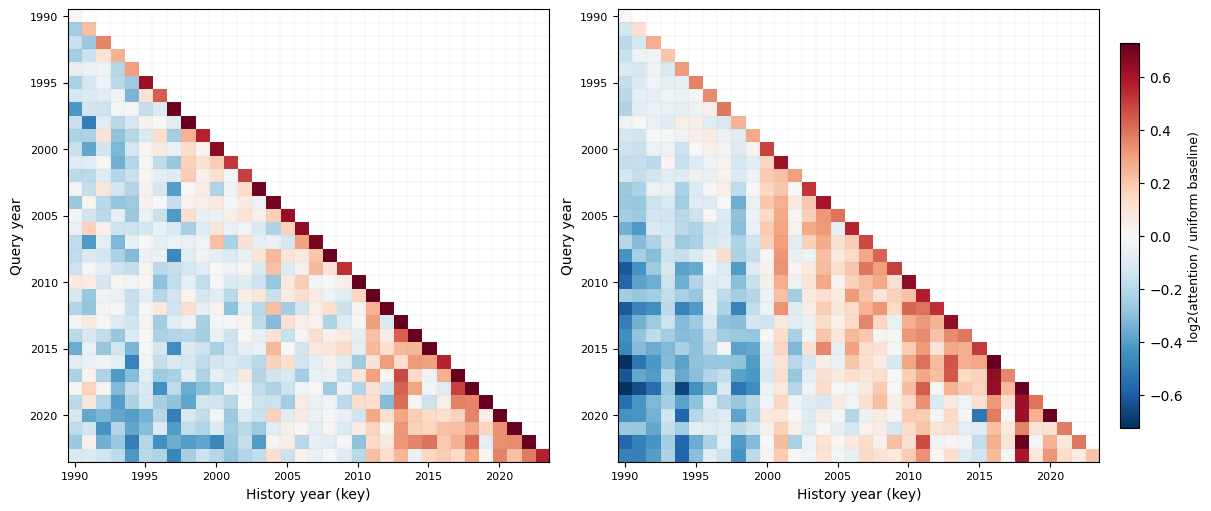

In [72]:
def attention_over_uniform(A: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """Softmaxed causal attention [T, T] -> log2(attention / uniform causal baseline)."""
    A = np.asarray(A, dtype=float)
    T = A.shape[0]
    out = np.full_like(A, np.nan, dtype=float)

    for t in range(T):
        baseline = 1.0 / (t + 1)
        out[t, :t+1] = np.log2((A[t, :t+1] + eps) / baseline)

    return out


attn_excess = {src: attention_over_uniform(attn[src].mean(dim=0).detach().cpu().numpy()) for src in SOURCES}

vmax = max(np.nanpercentile(np.abs(attn_excess[src]), 98) for src in SOURCES)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True, constrained_layout=True)

tick_pos = [k for k, y in enumerate(YEARS) if y % 5 == 0]
tick_label = [str(YEARS[k]) for k in tick_pos]

cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color='white')

for ax, src in zip(axes, SOURCES):
    im = ax.imshow(attn_excess[src], aspect='auto', origin='upper', cmap=cmap, norm=norm, interpolation='nearest')

    T = len(YEARS)
    ax.set_xticks(np.arange(-0.5, T, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, T, 1), minor=True)
    ax.grid(which='minor', color='gray', lw=0.1, alpha=0.5)
    ax.tick_params(which='minor', bottom=False, left=False)

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_label, fontsize=8)
    ax.set_yticks(tick_pos)
    ax.set_yticklabels(tick_label, fontsize=8)
    ax.tick_params(axis='y', labelleft=True)

    ax.set_xlabel('History year (key)', fontsize=10)
    ax.set_ylabel('Query year', fontsize=10)
    # ax.set_title(f'{src.upper()} — Attention over Uniform Baseline', fontweight='bold', fontsize=10)

cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.85, pad=0.02)
cbar.set_label('log2(attention / uniform baseline)', fontsize=9)
cbar.ax.tick_params(labelsize=10)

# fig.suptitle('Temporal Attention Relative to Uniform Causal Baseline', fontweight='bold', fontsize=11)

plt.savefig(ANALYSIS_DIR / '3-1_attn_heatmap_over_uniform.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Case Studies

Per-keyword integrated view:
```
Col 1: Drift, news + paper
Col 2: Co-occ degree, news + paper, twin y-axis
Col 3: Node attention heatmap, news subject
Col 4: Node attention heatmap, paper subject
```

In [29]:

def plot_drift_vs_cooc_case(subjects_by_src, save=True):
    srcs = [s for s in SOURCES if s in subjects_by_src]

    fig = plt.figure(figsize=(18.5, 3.6))
    gs = fig.add_gridspec(
        1, 5,
        width_ratios=[1.25, 1.25, 1, 1, 0.045],
        left=0.055, right=0.97, bottom=0.18, top=0.90, wspace=0.35
    )

    ax_drift = fig.add_subplot(gs[0, 0])
    ax_cooc = fig.add_subplot(gs[0, 1])
    ax_attn_news = fig.add_subplot(gs[0, 2])
    ax_attn_paper = fig.add_subplot(gs[0, 3])
    cax = fig.add_subplot(gs[0, 4])

    ax_cooc_twin = ax_cooc.twinx()

    axis_by_src = {
        'news':  {'drift': ax_drift, 'cooc': ax_cooc,      'attn': ax_attn_news},
        'paper': {'drift': ax_drift, 'cooc': ax_cooc_twin, 'attn': ax_attn_paper}
    }

    valid_srcs, attn_map = [], {}

    for src in srcs:
        subject = subjects_by_src[src]
        idx = get_idx(subject)

        if idx is None:
            print(f"[SKIP] {src}: '{subject}' not found in vocab")
            continue

        valid_srcs.append(src)
        color = SOURCE_COLORS[src]
        ax1, ax2 = axis_by_src[src]['drift'], axis_by_src[src]['cooc']

        d_ts = drift[src][:, idx].detach().cpu().numpy()
        c_ts = cooc_degree[src][:, idx]

        ax1.plot(YEARS[1:], d_ts, color=color, lw=2, label=src)
        ax2.plot(YEARS, c_ts, color=color, lw=2, label=src)

        A_node = attn[src][idx].detach().cpu().numpy()
        attn_map[src] = attention_over_uniform(A_node)

    if not valid_srcs:
        plt.close(fig)
        return

    # Drift axis
    ax_drift.set_ylabel('L2 Drift', fontsize=9)
    ax_drift.tick_params(axis='y', labelsize=7)
    ax_drift.set_title('Embedding Drift', fontsize=10)
    ax_drift.legend(fontsize=7, loc='upper right')

    # Co-occ axes
    ax_cooc.set_ylabel('news Co-occ Degree', fontsize=9)
    ax_cooc_twin.set_ylabel('paper Co-occ Degree', fontsize=9)
    ax_cooc.tick_params(axis='y', labelsize=7)
    ax_cooc_twin.tick_params(axis='y', labelsize=7)
    ax_cooc.set_title('Co-occ Degree', fontsize=10)

    h1, l1 = ax_cooc.get_legend_handles_labels()
    h2, l2 = ax_cooc_twin.get_legend_handles_labels()
    ax_cooc.legend(h1 + h2, l1 + l2, fontsize=7, loc='upper right')

    for ax in [ax_drift, ax_cooc]:
        add_events(ax)
        ax.set_xlim(YEAR_START, YEAR_END)
        ax.set_xlabel('Year', fontsize=9)
        ax.tick_params(axis='x', labelsize=7)
        ax.grid(alpha=0.2)

    # Attention heatmaps
    tick_pos = [k for k, y in enumerate(YEARS) if y % 5 == 0]
    tick_label = [str(YEARS[k]) for k in tick_pos]

    vmax = max(np.nanpercentile(np.abs(attn_map[src]), 98) for src in valid_srcs)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color='white')

    im = None
    for src in valid_srcs:
        ax = axis_by_src[src]['attn']
        subject = subjects_by_src[src]

        im = ax.imshow(attn_map[src], aspect='auto', origin='upper', cmap=cmap, norm=norm, interpolation='nearest')

        T = len(YEARS)
        ax.set_xticks(np.arange(-0.5, T, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, T, 1), minor=True)
        ax.grid(which='minor', color='gray', lw=0.1, alpha=0.5)
        ax.tick_params(which='minor', bottom=False, left=False)

        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_label, rotation=90, fontsize=6)
        ax.set_yticks(tick_pos)
        ax.set_yticklabels(tick_label, fontsize=6)
        ax.tick_params(axis='y', labelleft=True)

        ax.set_xlabel('History year', fontsize=8)
        ax.set_ylabel('Query year', fontsize=8)
        ax.set_title(f'Node Attention [{src.upper()}]\n{subject}', fontsize=9)

        for yr in KEY_EVENTS:
            if yr in YEARS:
                ti = YEARS.index(yr)
                ax.axvline(ti, color='gray', lw=0.5, ls='--', alpha=0.45)
                ax.axhline(ti, color='gray', lw=0.5, ls='--', alpha=0.45)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('log2(attention / uniform)', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    news_subject = subjects_by_src.get('news', list(subjects_by_src.values())[0])
    fig.text(0.015, 0.5, news_subject, va='center', ha='center', rotation=90, fontsize=11)

    if save:
        fname = news_subject.replace(' ', '_').replace('/', '_')
        plt.savefig(ANALYSIS_DIR / f'case_{fname}_drift_cooc_attn.png', dpi=150, bbox_inches='tight')



Valid subject pairs (6):
  NEWS: artificial intelligence  |  PAPER: applications of artificial intelligence
  NEWS: productivity  |  PAPER: productivity
  NEWS: health care  |  PAPER: health care
  NEWS: deep learning  |  PAPER: deep learning
  NEWS: automation  |  PAPER: automation
  NEWS: machine learning  |  PAPER: machine learning


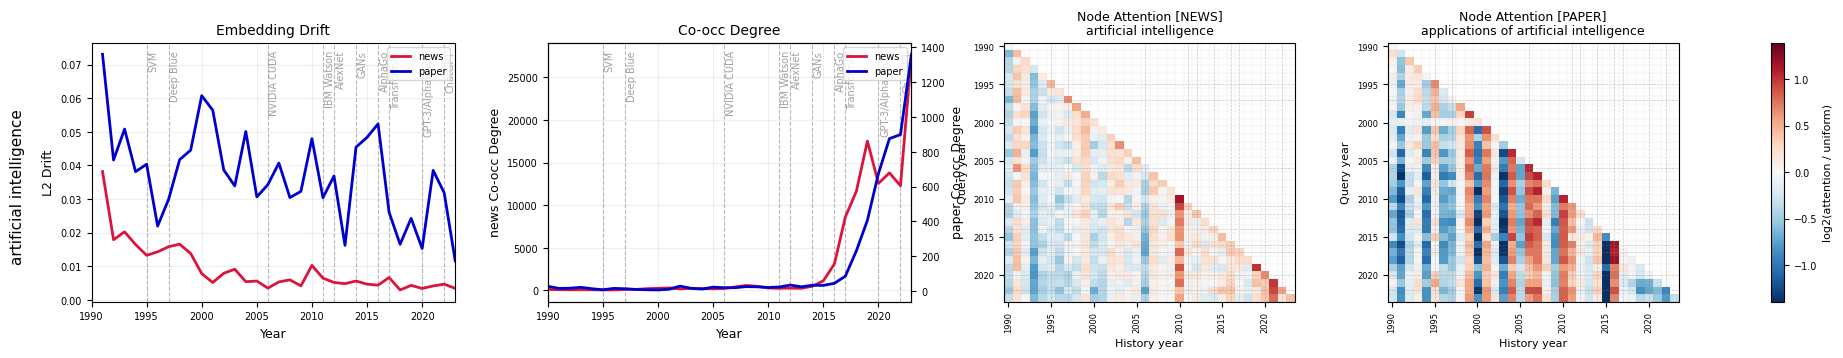

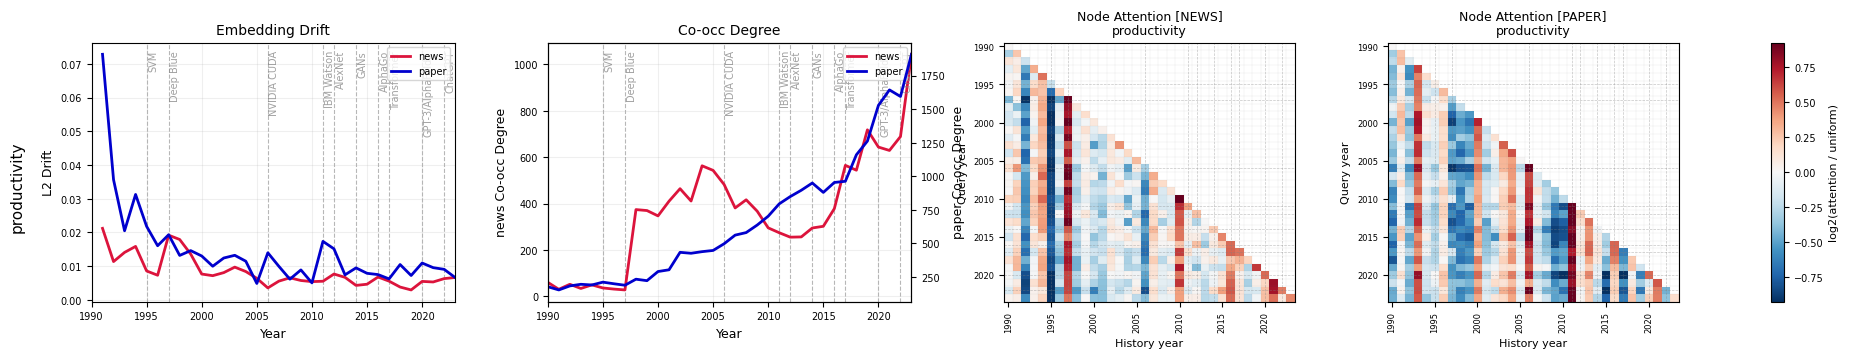

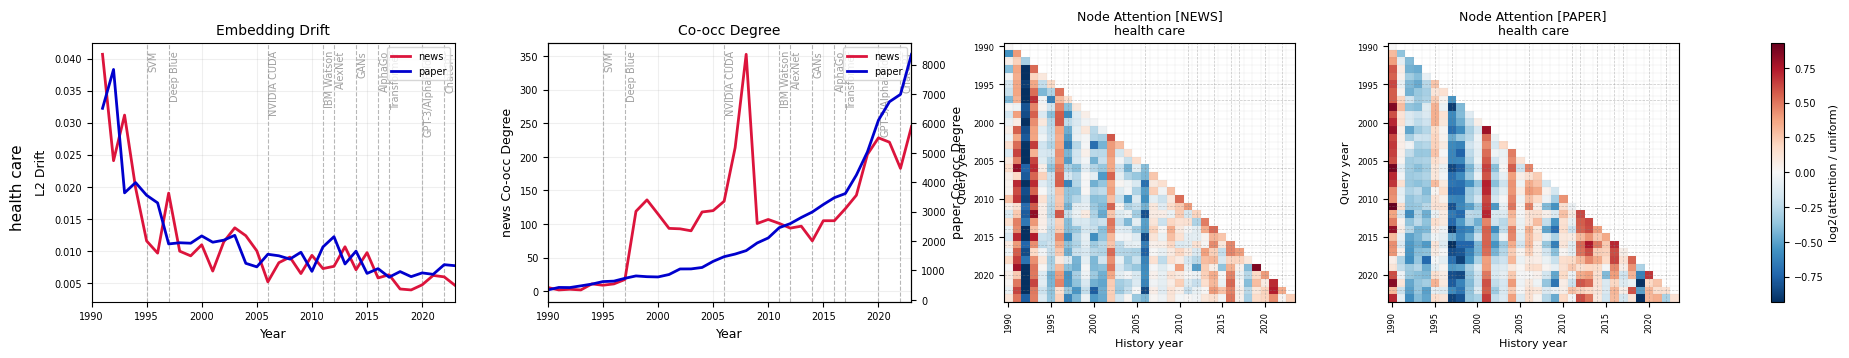

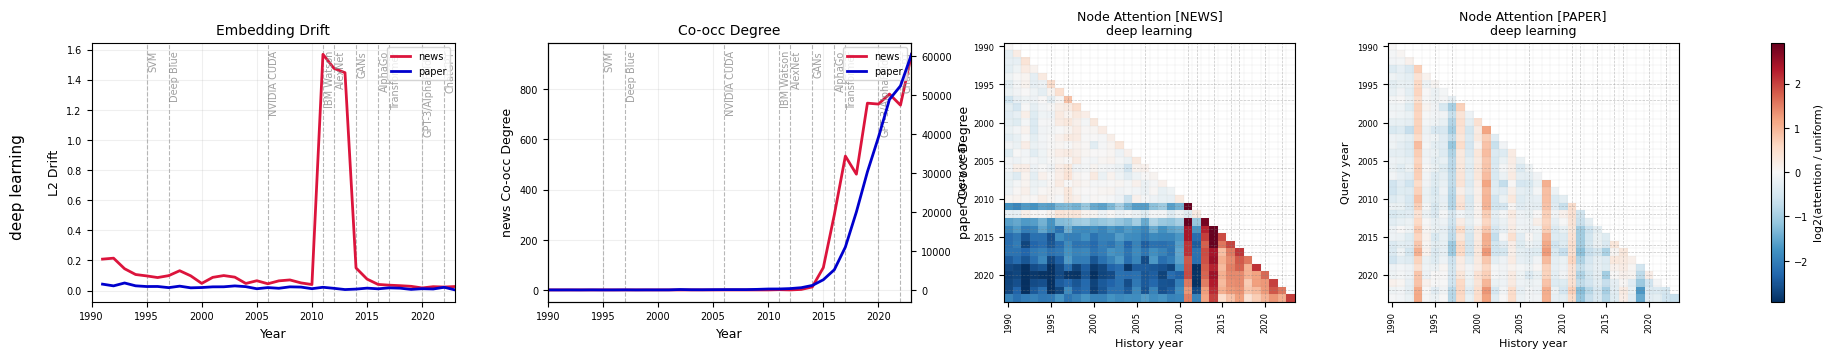

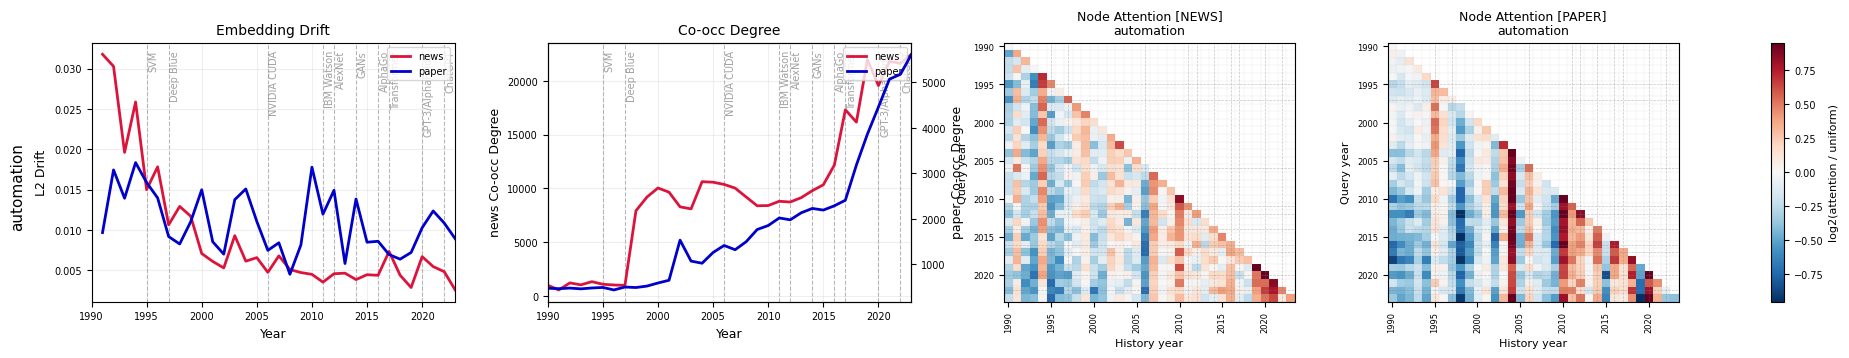

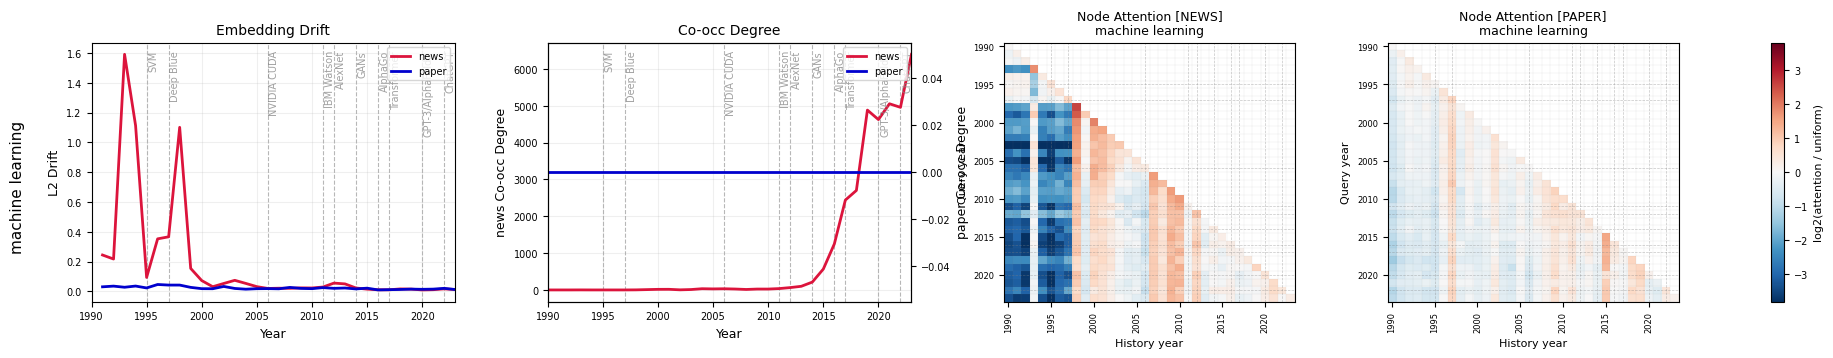

In [30]:
CASE_SUBJECT_PAIRS = [
    ("artificial intelligence", "applications of artificial intelligence"),
    ("productivity", "productivity"),
    ("health care", "health care"),
    ("deep learning", "deep learning"),
    ("automation", "automation"),
    ("machine learning", "machine learning")
]

print(f"Valid subject pairs ({len(CASE_SUBJECT_PAIRS)}):")
for news_s, paper_s in CASE_SUBJECT_PAIRS:
    print(f"  NEWS: {news_s}  |  PAPER: {paper_s}")


for news_s, paper_s in CASE_SUBJECT_PAIRS:
    plot_drift_vs_cooc_case({
        'news': news_s,
        'paper': paper_s
    })

In [31]:
import re

def to_numpy(x):
    return x.detach().cpu().numpy() if hasattr(x, "detach") else np.asarray(x)

SOURCE_APPEARED = {"news": news_appeared, "paper": paper_appeared}

def get_group_terms(query: str, top_k: int = None, src: str = None, min_degree: float = None, verbose: bool = True):
    q = query.lower()
    raw_hits = [s for s in subjects if q in s.lower()]

    if src is not None:
        if src not in SOURCE_APPEARED:
            raise ValueError(f"unknown src: {src}")
        hits = [s for s in raw_hits if SOURCE_APPEARED[src][subj_idx[s]]]
    else:
        hits = raw_hits

    def degree_score(s):
        idx = subj_idx[s]
        if src is None:
            return sum(np.nansum(to_numpy(cooc_degree[x][:, idx])) for x in SOURCES)
        return np.nansum(to_numpy(cooc_degree[src][:, idx]))

    scored_hits = [(s, degree_score(s)) for s in hits]

    if min_degree is not None:
        scored_hits = [(s, deg) for s, deg in scored_hits if deg >= min_degree]

    scored_hits = sorted(scored_hits, key=lambda x: x[1], reverse=True)
    terms = [s for s, deg in scored_hits] if top_k is None else [s for s, deg in scored_hits[:top_k]]

    if verbose:
        scope = "pooled" if src is None else src
        print(f"'{query}' [{scope}] -> raw={len(raw_hits):,}, usable={len(hits):,}, degree>={min_degree}: {len(scored_hits):,}, using={len(terms):,}")
        for s, deg in scored_hits[:10 if top_k is None else min(10, top_k)]:
            idx = subj_idx[s]
            print(f"  [{idx:6d}] {s}  news={news_appeared[idx]} paper={paper_appeared[idx]} degree={deg:.0f}")

    return terms

def get_group_idx_from_terms(terms, src: str = None):
    idxs = []
    for t in terms:
        if t not in subj_idx:
            print(f"'{t}' not found.")
            continue
        idx = subj_idx[t]
        if src is not None and not SOURCE_APPEARED[src][idx]:
            continue
        idxs.append(idx)
    return idxs

def group_drift_quantiles(src, terms, min_active_degree=2):
    idxs = get_group_idx_from_terms(terms, src=src)
    if not idxs:
        return None
    d   = to_numpy(drift[src][:, idxs])
    deg = cooc_degree[src][:, idxs]
    valid = (deg[:-1] >= min_active_degree) & (deg[1:] >= min_active_degree)
    d[~valid] = np.nan
    return np.nanpercentile(d, [25, 50, 75], axis=1)

def group_cooc_ts(src, terms, agg='sum'):
    idxs = get_group_idx_from_terms(terms, src=src)
    if not idxs:
        return None
    c = to_numpy(cooc_degree[src][:, idxs])
    if agg == 'sum':
        return np.nansum(c, axis=1)
    if agg == 'median':
        return np.nanmedian(c, axis=1)
    if agg == 'mean':
        return np.nanmean(c, axis=1)
    raise ValueError("agg must be 'sum', 'median', or 'mean'")

def group_attention_map(src, terms):
    idxs = get_group_idx_from_terms(terms, src=src)
    if not idxs:
        return None
    A = to_numpy(attn[src][idxs])
    A = np.nanmean(A, axis=0)
    return attention_over_uniform(A)

def plot_group_drift_vs_cooc_case(queries_by_src, top_k=None,  min_degree=100, save=True):
    srcs = [s for s in ["news", "paper"] if s in SOURCES and s in queries_by_src]
    fig = plt.figure(figsize=(18.5, 3.6))
    gs = fig.add_gridspec(1, 5, width_ratios=[1, 1, 1, 1, 0.045], left=0.055, right=0.97, bottom=0.18, top=0.90, wspace=0.35)
    ax_drift = fig.add_subplot(gs[0, 0])
    ax_cooc = fig.add_subplot(gs[0, 1])
    ax_attn_news = fig.add_subplot(gs[0, 2])
    ax_attn_paper = fig.add_subplot(gs[0, 3])
    cax = fig.add_subplot(gs[0, 4])
    ax_cooc_twin = ax_cooc.twinx()
    axis_by_src = {"news": {"drift": ax_drift, "cooc": ax_cooc, "attn": ax_attn_news}, "paper": {"drift": ax_drift, "cooc": ax_cooc_twin, "attn": ax_attn_paper}}
    valid_srcs, group_terms_by_src, attn_map = [], {}, {}
    for src in srcs:
        query = queries_by_src[src]
        terms = get_group_terms(query, top_k=top_k, src=src, min_degree=min_degree, verbose=True)
        idxs = get_group_idx_from_terms(terms, src=src)
        if not idxs:
            print(f"[SKIP] {src}: no valid {src} terms for query '{query}'")
            continue
        q = group_drift_quantiles(src, terms)
        c_ts = group_cooc_ts(src, terms, agg='sum')
        A = group_attention_map(src, terms)
        if q is None or c_ts is None or A is None:
            print(f"[SKIP] {src}: failed to build series for query '{query}'")
            continue
        valid_srcs.append(src)
        group_terms_by_src[src] = terms
        attn_map[src] = A
        q25, q50, q75 = q
        color = SOURCE_COLORS[src]
        axis_by_src[src]['drift'].plot(YEARS[1:], q50, color=color, lw=2, label=f"{src} median (n={len(idxs)})")
        axis_by_src[src]['cooc'].plot(YEARS, c_ts, color=color, lw=2, label=f"{src} (n={len(idxs)})")
    if not valid_srcs:
        plt.close(fig)
        return
    ax_drift.set_ylabel('Group median L2 Drift', fontsize=9)
    ax_drift.tick_params(axis='y', labelsize=7)
    ax_drift.set_title('Embedding Drift', fontsize=10)
    ax_drift.legend(fontsize=7, loc='upper right')
    # drift plot 그린 후
    y_data_max = ax_drift.get_ylim()[1]
    ax_drift.set_ylim(0, max(y_data_max, 0.15))
    
    ax_cooc.set_ylabel('news Group Co-occ Degree', fontsize=9)
    ax_cooc_twin.set_ylabel('paper Group Co-occ Degree', fontsize=9)
    ax_cooc.tick_params(axis='y', labelsize=7)
    ax_cooc_twin.tick_params(axis='y', labelsize=7)
    ax_cooc.set_title('Co-occ Degree', fontsize=10)
    h1, l1 = ax_cooc.get_legend_handles_labels()
    h2, l2 = ax_cooc_twin.get_legend_handles_labels()
    ax_cooc.legend(h1 + h2, l1 + l2, fontsize=7, loc='upper right')
    for ax in [ax_drift, ax_cooc]:
        add_events(ax)
        ax.set_xlim(YEAR_START, YEAR_END)
        ax.set_xlabel('Year', fontsize=9)
        ax.tick_params(axis='x', labelsize=7)
        ax.grid(alpha=0.2)
    tick_pos = [k for k, y in enumerate(YEARS) if y % 5 == 0]
    tick_label = [str(YEARS[k]) for k in tick_pos]
    vmax_vals = [np.nanpercentile(np.abs(attn_map[src]), 98) for src in valid_srcs if np.isfinite(np.nanpercentile(np.abs(attn_map[src]), 98))]
    vmax = max(vmax_vals) if vmax_vals else 1.0
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color='white')
    im = None
    for src in valid_srcs:
        ax = axis_by_src[src]['attn']
        query = queries_by_src[src]
        n_terms = len(get_group_idx_from_terms(group_terms_by_src[src], src=src))
        im = ax.imshow(attn_map[src], aspect='auto', origin='upper', cmap=cmap, norm=norm, interpolation='nearest')
        T = len(YEARS)
        ax.set_xticks(np.arange(-0.5, T, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, T, 1), minor=True)
        ax.grid(which='minor', color='gray', lw=0.1, alpha=0.5)
        ax.tick_params(which='minor', bottom=False, left=False)
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(tick_label, rotation=90, fontsize=6)
        ax.set_yticks(tick_pos)
        ax.set_yticklabels(tick_label, fontsize=6)
        ax.tick_params(axis='y', labelleft=True)
        ax.set_xlabel('History year', fontsize=8)
        ax.set_ylabel('Query year', fontsize=8)
        ax.set_title(f'Group Attention [{src.upper()}]\n{query} (n={n_terms})', fontsize=9)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('log2(attention / uniform)', fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    main_query = queries_by_src.get('news', list(queries_by_src.values())[0])
    fig.text(0.015, 0.5, main_query, va='center', ha='center', rotation=90, fontsize=11)
    if save:
        fname = re.sub(r'[^A-Za-z0-9_.-]+', '_', main_query).strip('_')
        plt.savefig(ANALYSIS_DIR / f'group_{fname}_drift_cooc_attn.png', dpi=150, bbox_inches='tight')



=== artificial intelligence ===
'artificial intelligence' [news] -> raw=11, usable=6, degree>=100: 2, using=2
  [  1472] artificial intelligence  news=True paper=False degree=113473
  [ 11180] generative artificial intelligence  news=True paper=False degree=1531
'artificial intelligence' [paper] -> raw=11, usable=5, degree>=100: 5, using=5
  [  1148] anticipation (artificial intelligence)  news=False paper=True degree=25345
  [  1267] applications of artificial intelligence  news=False paper=True degree=5094
  [  1473] artificial intelligence system  news=False paper=True degree=974
  [  1474] artificial intelligence, situated approach  news=False paper=True degree=845
  [ 17412] music and artificial intelligence  news=False paper=True degree=406


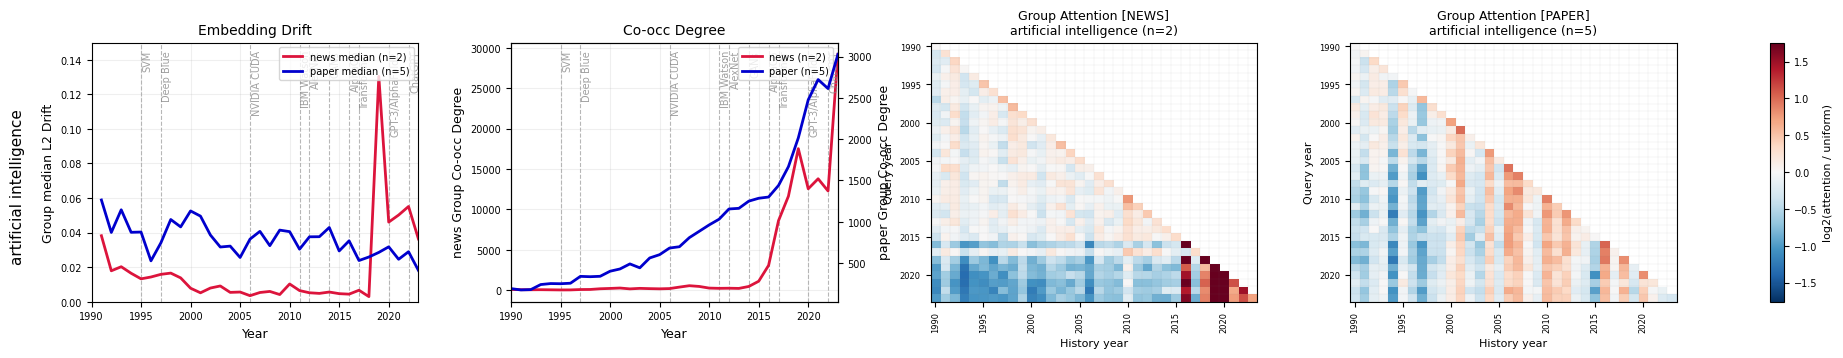


=== machine learning ===
'machine learning' [news] -> raw=5, usable=1, degree>=100: 1, using=1
  [ 15616] machine learning  news=True paper=False degree=33534
'machine learning' [paper] -> raw=5, usable=4, degree>=100: 4, using=4
  [   291] active learning (machine learning)  news=False paper=True degree=37298
  [  2892] boosting (machine learning)  news=False paper=True degree=33204
  [ 15854] margin (machine learning)  news=False paper=True degree=25114
  [ 23670] semantic analysis (machine learning)  news=False paper=True degree=2771


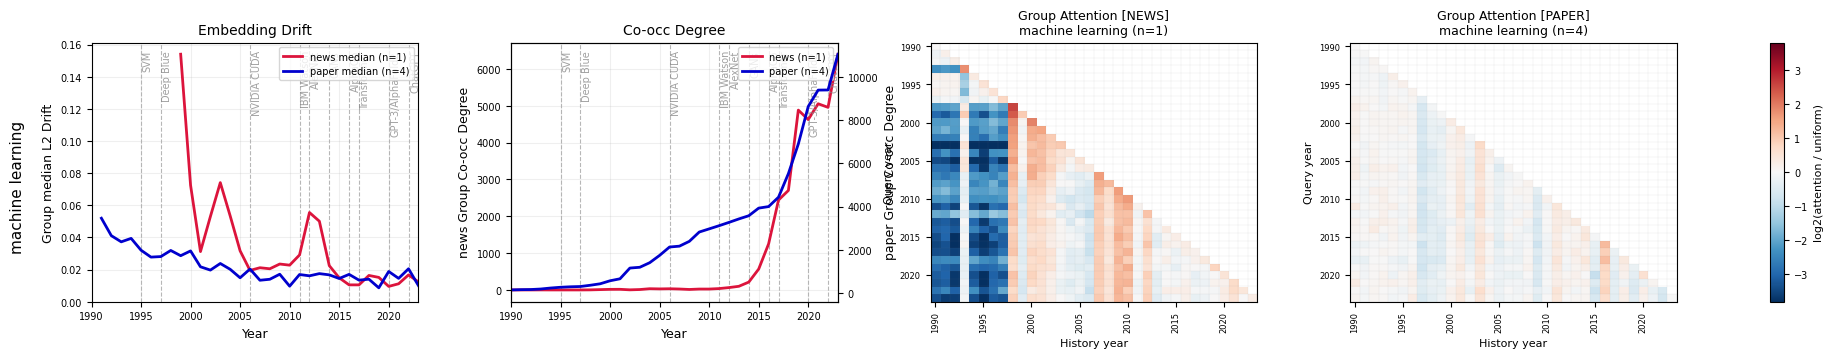


=== deep learning ===
'deep learning' [news] -> raw=1, usable=1, degree>=100: 1, using=1
  [  6868] deep learning  news=True paper=True degree=5339
'deep learning' [paper] -> raw=1, usable=1, degree>=100: 1, using=1
  [  6868] deep learning  news=True paper=True degree=273829


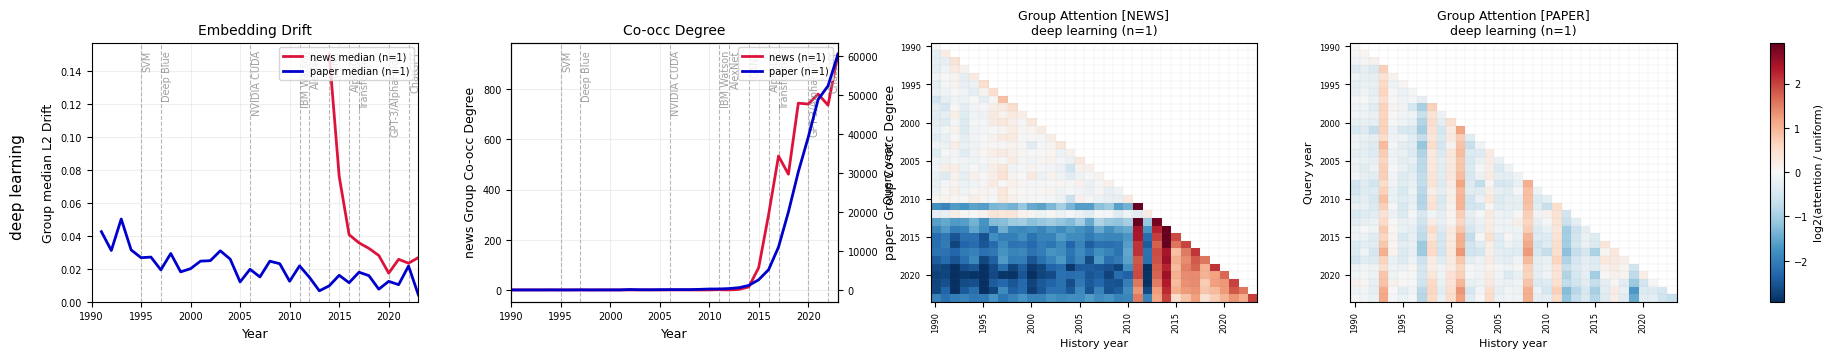


=== neural network ===
'neural network' [news] -> raw=6, usable=2, degree>=100: 1, using=1
  [ 17863] neural networks  news=True paper=False degree=7613
'neural network' [paper] -> raw=6, usable=4, degree>=100: 4, using=4
  [  1479] artificial neural network  news=False paper=True degree=875376
  [  5763] convolutional neural network  news=False paper=True degree=222719
  [  7928] dropout (neural networks)  news=False paper=True degree=8213
  [  2514] biological neural network  news=False paper=True degree=4557


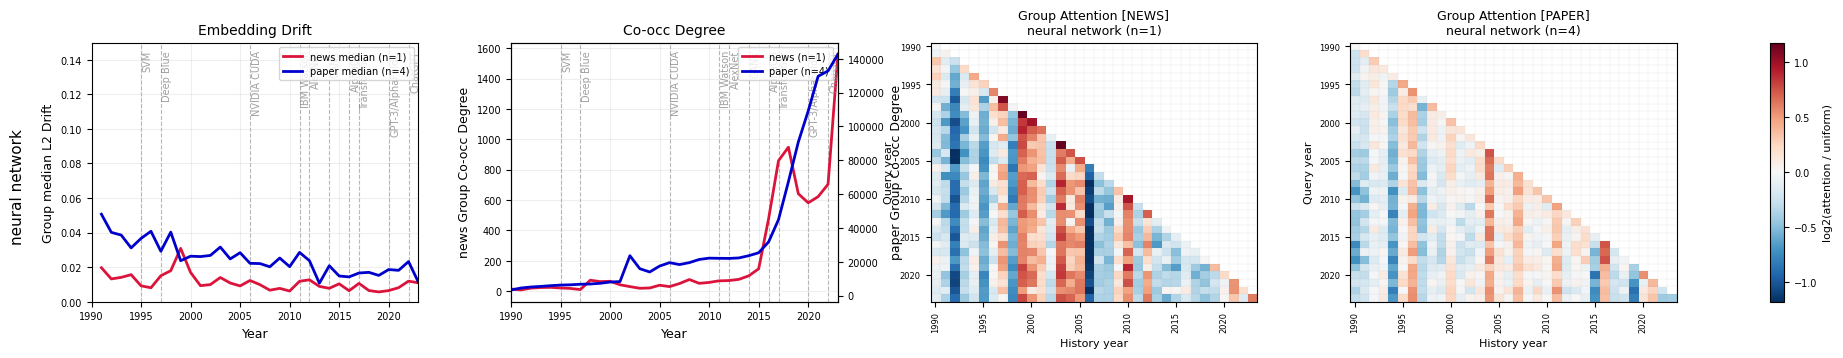


=== automation ===
'automation' [news] -> raw=10, usable=7, degree>=100: 6, using=5
  [  1827] automation  news=True paper=True degree=328706
  [  3160] building automation  news=True paper=True degree=8659
  [ 18413] office automation  news=True paper=True degree=6295
  [  8533] electronic design automation  news=True paper=True degree=3925
  [  2049] bank automation  news=True paper=False degree=3232
'automation' [paper] -> raw=10, usable=7, degree>=100: 7, using=5
  [  1827] automation  news=True paper=True degree=61289
  [ 22958] routing (electronic design automation)  news=False paper=True degree=35918
  [ 12515] home automation  news=False paper=True degree=4710
  [  3160] building automation  news=True paper=True degree=3626
  [  8533] electronic design automation  news=True paper=True degree=1233


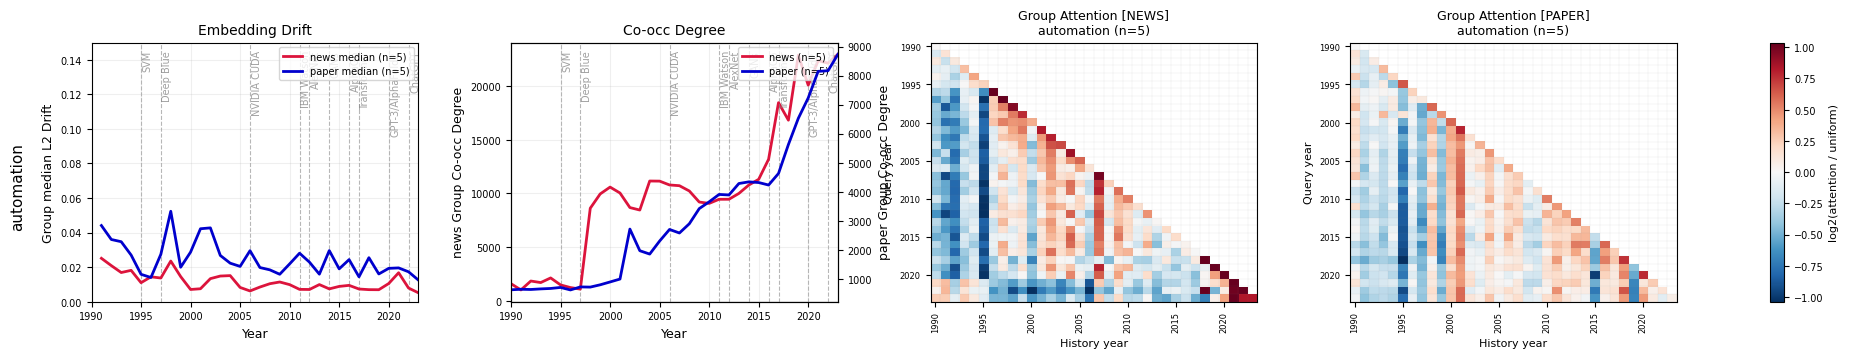


=== health care ===
'health care' [news] -> raw=14, usable=14, degree>=100: 10, using=5
  [ 12048] health care industry  news=True paper=False degree=5163
  [ 12044] health care  news=True paper=True degree=3779
  [ 12050] health care policy  news=True paper=False degree=2941
  [ 12047] health care expenditures  news=True paper=False degree=999
  [ 12045] health care access  news=True paper=False degree=514
'health care' [paper] -> raw=14, usable=1, degree>=100: 1, using=1
  [ 12044] health care  news=True paper=True degree=79212


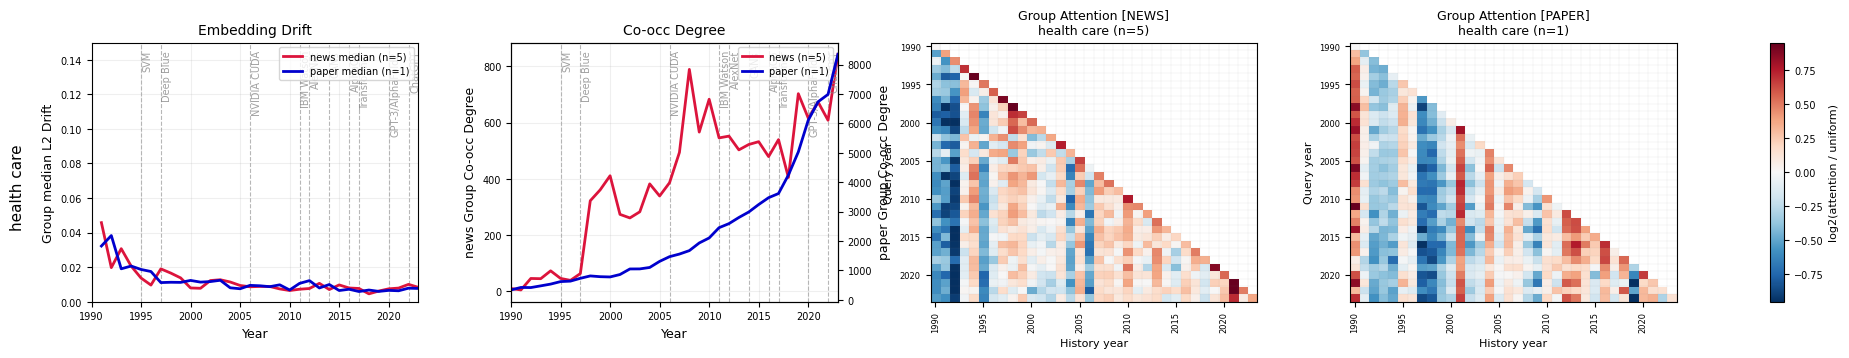


=== education ===
'education' [news] -> raw=149, usable=89, degree>=100: 26, using=5
  [  8305] education  news=True paper=False degree=7821
  [ 12373] higher education  news=True paper=True degree=2670
  [ 25384] stem education  news=True paper=False degree=1874
  [  8337] educational technology  news=True paper=True degree=1669
  [ 23333] science education  news=True paper=True degree=1323
'education' [paper] -> raw=149, usable=91, degree>=100: 65, using=5
  [ 27162] tracking (education)  news=False paper=True degree=164447
  [ 12373] higher education  news=True paper=True degree=32595
  [  8337] educational technology  news=True paper=True degree=19869
  [ 28517] vocational education  news=True paper=True degree=15881
  [ 23333] science education  news=True paper=True degree=12262


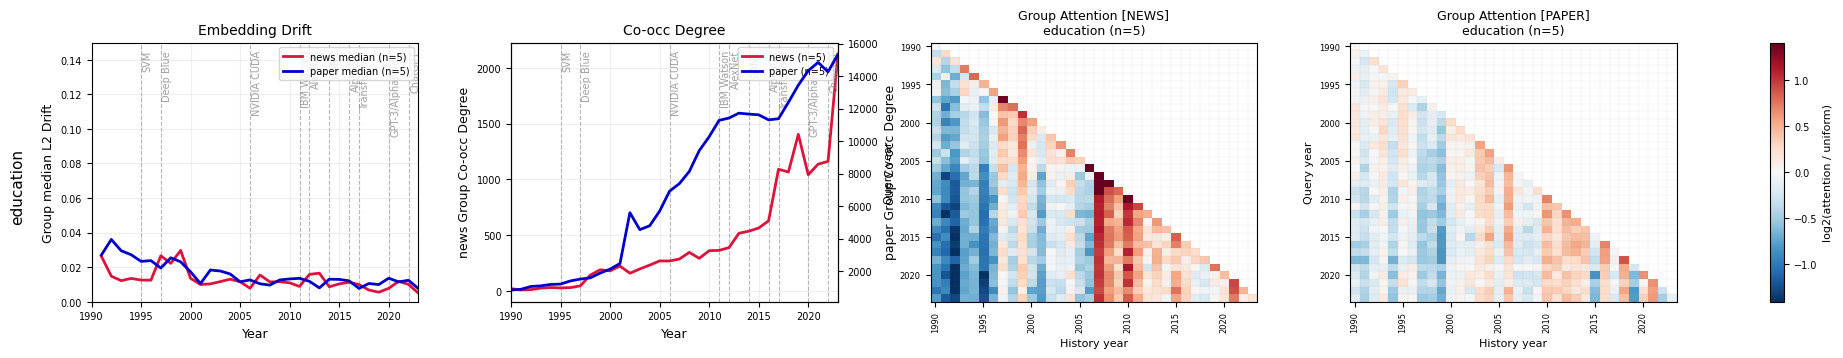


=== employment ===
'employment' [news] -> raw=25, usable=25, degree>=100: 8, using=5
  [  8752] employment  news=True paper=False degree=10249
  [ 27794] unemployment  news=True paper=True degree=1112
  [ 27796] unemployment benefits  news=True paper=False degree=263
  [  8756] employment interviews  news=True paper=False degree=248
  [ 27797] unemployment insurance  news=True paper=False degree=194
'employment' [paper] -> raw=25, usable=2, degree>=100: 2, using=2
  [ 27794] unemployment  news=True paper=True degree=4355
  [  8755] employment discrimination  news=True paper=True degree=157


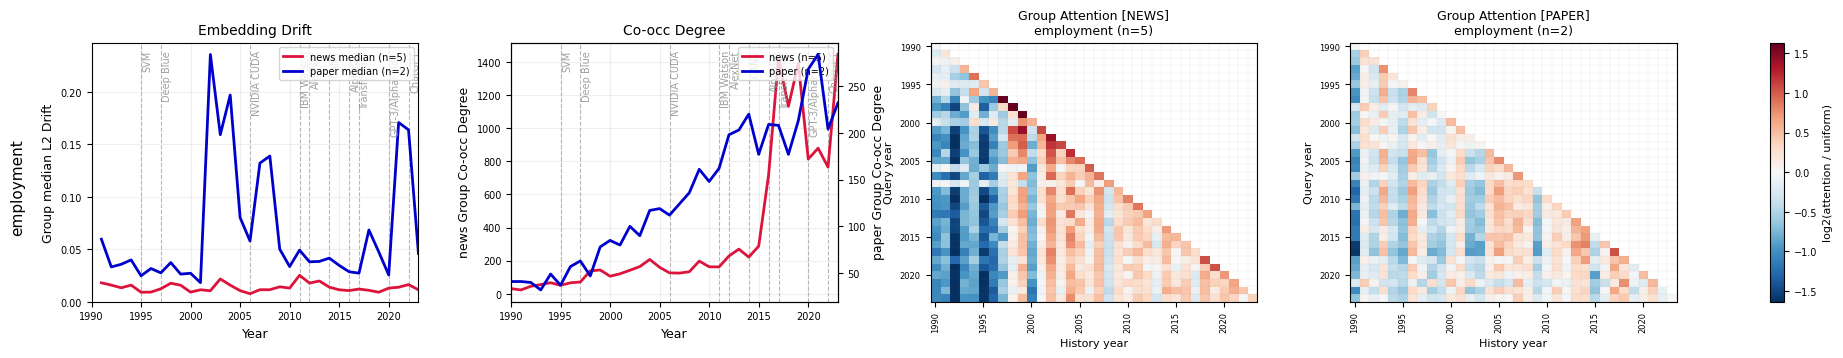


=== productivity ===
'productivity' [news] -> raw=4, usable=4, degree>=100: 2, using=2
  [ 21114] productivity  news=True paper=True degree=12331
  [ 14530] labor productivity  news=True paper=False degree=192
'productivity' [paper] -> raw=4, usable=1, degree>=100: 1, using=1
  [ 21114] productivity  news=True paper=True degree=22667


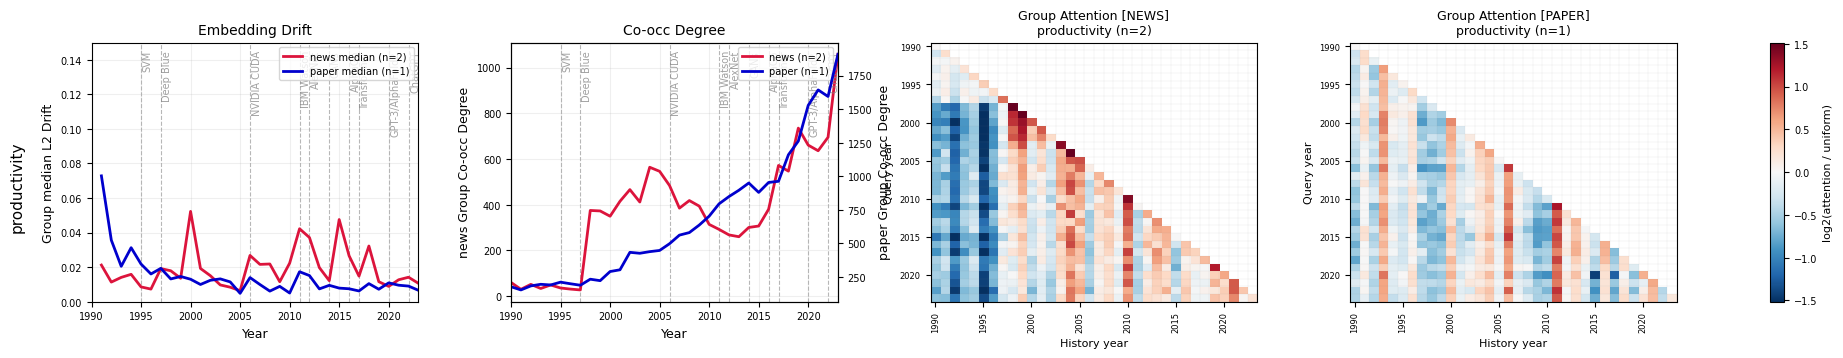


=== industr ===
'industr' [news] -> raw=232, usable=187, degree>=100: 88, using=5
  [ 24658] software industry  news=True paper=False degree=24254
  [  8581] electronics industry  news=True paper=False degree=8063
  [  1839] automobile industry  news=True paper=False degree=6036
  [ 19790] pharmaceutical industry  news=True paper=True degree=5375
  [ 12048] health care industry  news=True paper=False degree=5163
'industr' [paper] -> raw=232, usable=76, degree>=100: 42, using=5
  [  1859] automotive industry  news=False paper=True degree=25330
  [ 13383] industry 4.0  news=True paper=True degree=2949
  [ 13368] industrial revolution  news=True paper=True degree=2328
  [  5531] construction industry  news=True paper=True degree=2265
  [ 13380] industrialisation  news=False paper=True degree=2077


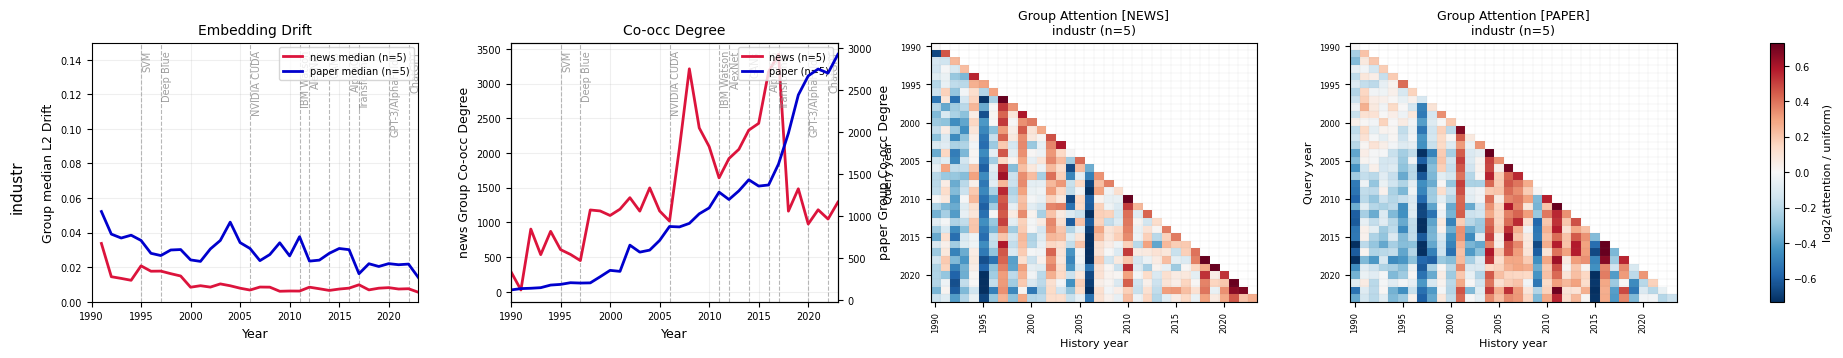


=== creativ ===
'creativ' [news] -> raw=6, usable=4, degree>=100: 1, using=1
  [  6114] creativity  news=True paper=True degree=537
'creativ' [paper] -> raw=6, usable=5, degree>=100: 5, using=5
  [  6114] creativity  news=True paper=True degree=40466
  [  6113] creative writing  news=True paper=True degree=589
  [  6110] creative industries  news=True paper=True degree=542
  [  6112] creative work  news=False paper=True degree=379
  [  6109] creative destruction  news=False paper=True degree=171


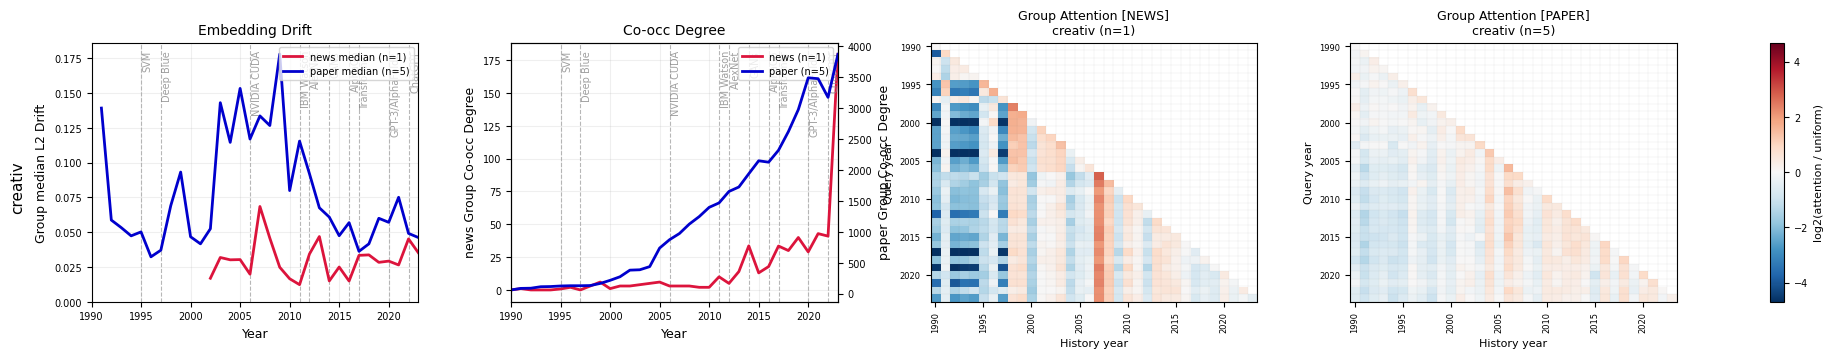


=== arts ===
'arts' [news] -> raw=32, usable=22, degree>=100: 7, using=5
  [ 11609] graphic arts  news=True paper=True degree=348
  [   537] aftermarket parts  news=True paper=False degree=345
  [  1861] automotive parts  news=True paper=False degree=258
  [ 19611] performing arts  news=True paper=True degree=191
  [ 12696] housing starts  news=True paper=False degree=131
'arts' [paper] -> raw=32, usable=14, degree>=100: 6, using=5
  [ 25697] style (visual arts)  news=False paper=True degree=28136
  [ 26671] the arts  news=False paper=True degree=9693
  [ 19611] performing arts  news=True paper=True degree=1864
  [ 15971] martial arts  news=True paper=True degree=782
  [ 14632] language arts  news=True paper=True degree=489


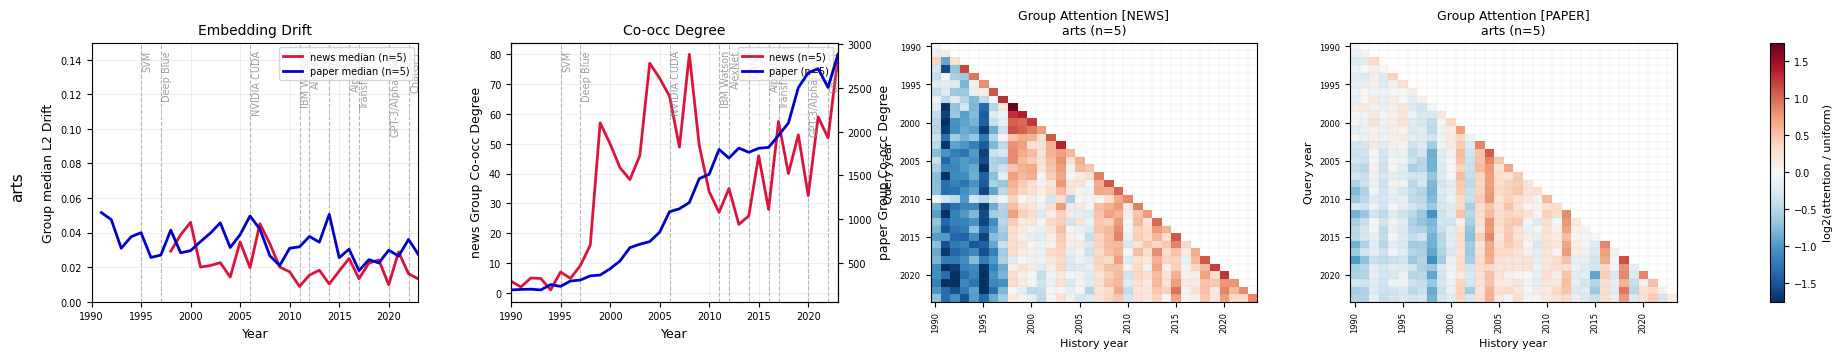


=== automobile ===
'automobile' [news] -> raw=29, usable=28, degree>=100: 14, using=5
  [  1839] automobile industry  news=True paper=False degree=6036
  [  1854] automobiles  news=True paper=False degree=3342
  [  1850] automobile safety  news=True paper=False degree=1578
  [  1832] automobile dealers  news=True paper=False degree=1148
  [  1833] automobile drivers  news=True paper=False degree=777
'automobile' [paper] -> raw=29, usable=2, degree>=100: 2, using=2
  [  1838] automobile handling  news=False paper=True degree=2570
  [  1840] automobile insurance  news=True paper=True degree=206


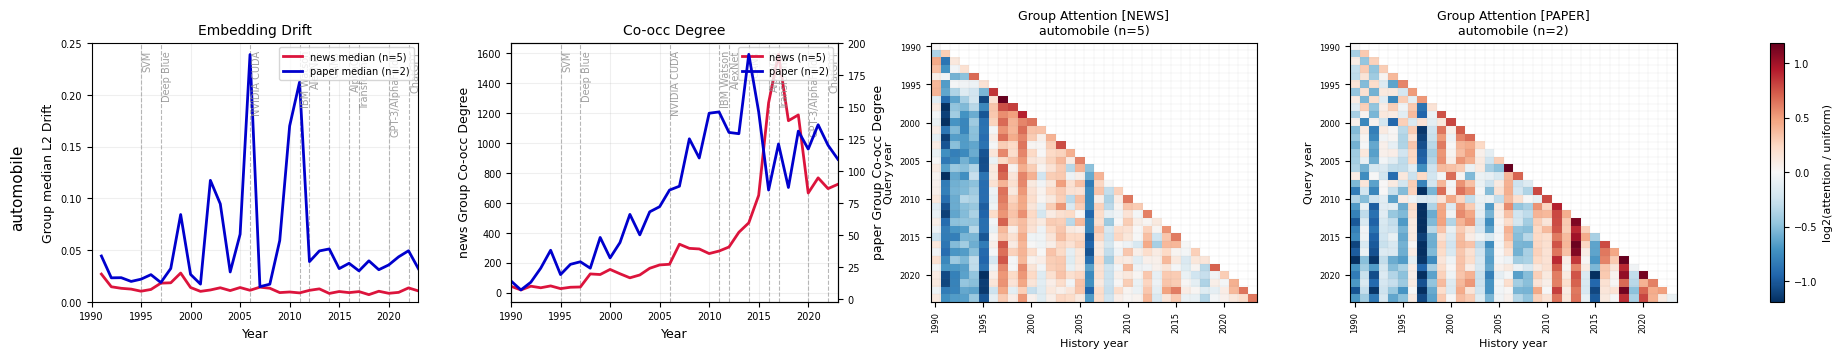


=== pharmaceut ===
'pharmaceut' [news] -> raw=9, usable=4, degree>=100: 3, using=3
  [ 19790] pharmaceutical industry  news=True paper=True degree=5375
  [ 19794] pharmaceuticals  news=True paper=False degree=1872
  [ 19792] pharmaceutical sciences  news=True paper=True degree=122
'pharmaceut' [paper] -> raw=9, usable=7, degree>=100: 4, using=4
  [ 19790] pharmaceutical industry  news=True paper=True degree=1491
  [  2555] biopharmaceutical  news=False paper=True degree=423
  [ 19791] pharmaceutical manufacturing  news=False paper=True degree=311
  [ 19792] pharmaceutical sciences  news=True paper=True degree=134


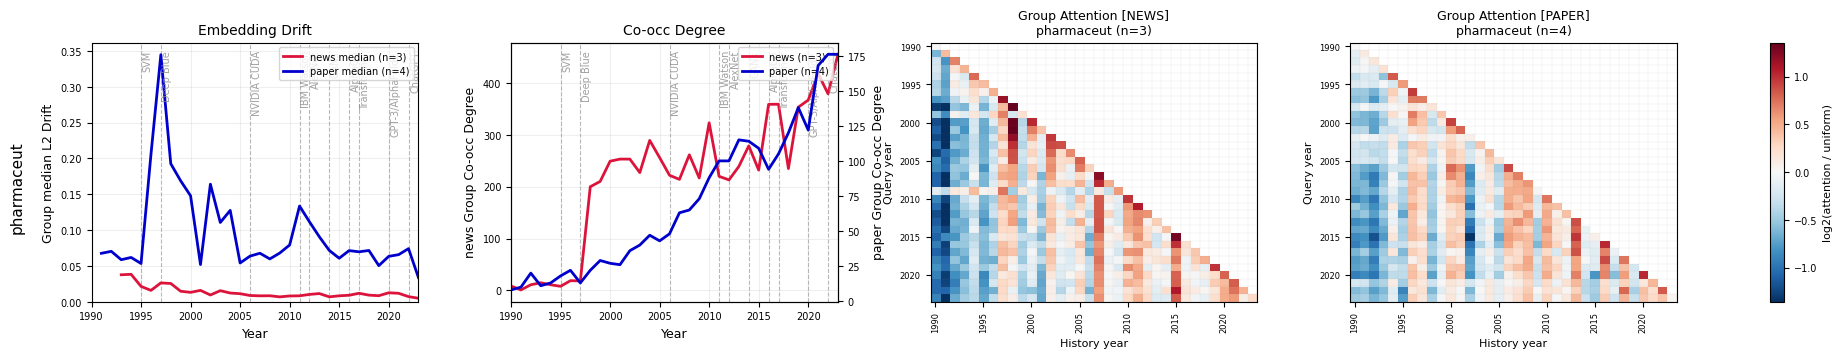


=== privacy ===
'privacy' [news] -> raw=12, usable=9, degree>=100: 4, using=4
  [ 20969] privacy  news=True paper=False degree=8393
  [ 22766] right of privacy  news=True paper=False degree=239
  [  5275] computer privacy  news=True paper=False degree=224
  [  4153] chief privacy officers  news=True paper=False degree=194
'privacy' [paper] -> raw=12, usable=4, degree>=100: 4, using=4
  [ 13487] information privacy  news=False paper=True degree=10248
  [  7338] differential privacy  news=False paper=True degree=5387
  [ 20972] privacy protection  news=False paper=True degree=1762
  [ 22771] right to privacy  news=True paper=True degree=221


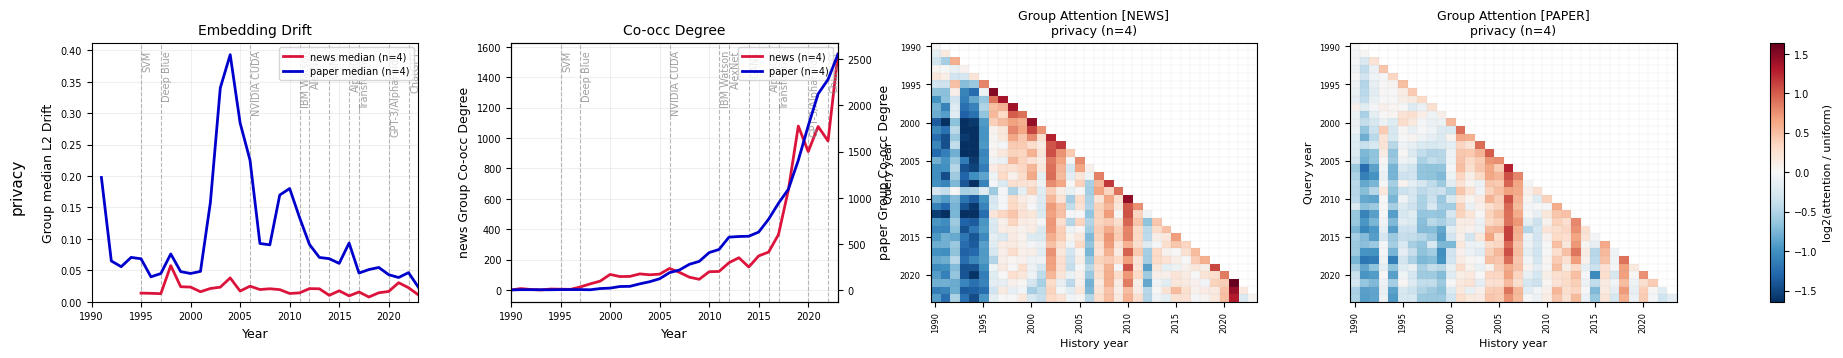


=== regulation ===
'regulation' [news] -> raw=37, usable=30, degree>=100: 8, using=5
  [ 22294] regulation  news=True paper=False degree=1532
  [ 22302] regulation of financial institutions  news=True paper=False degree=1029
  [  9855] federal regulation  news=True paper=False degree=640
  [ 11144] general data protection regulation  news=True paper=False degree=359
  [ 10149] firearm laws & regulations  news=True paper=False degree=324
'regulation' [paper] -> raw=37, usable=9, degree>=100: 6, using=5
  [  7082] deregulation  news=True paper=True degree=811
  [ 10078] financial regulation  news=False paper=True degree=392
  [  8701] emotional regulation  news=True paper=True degree=305
  [  8996] environmental regulation  news=False paper=True degree=303
  [ 26780] thermoregulation  news=False paper=True degree=225


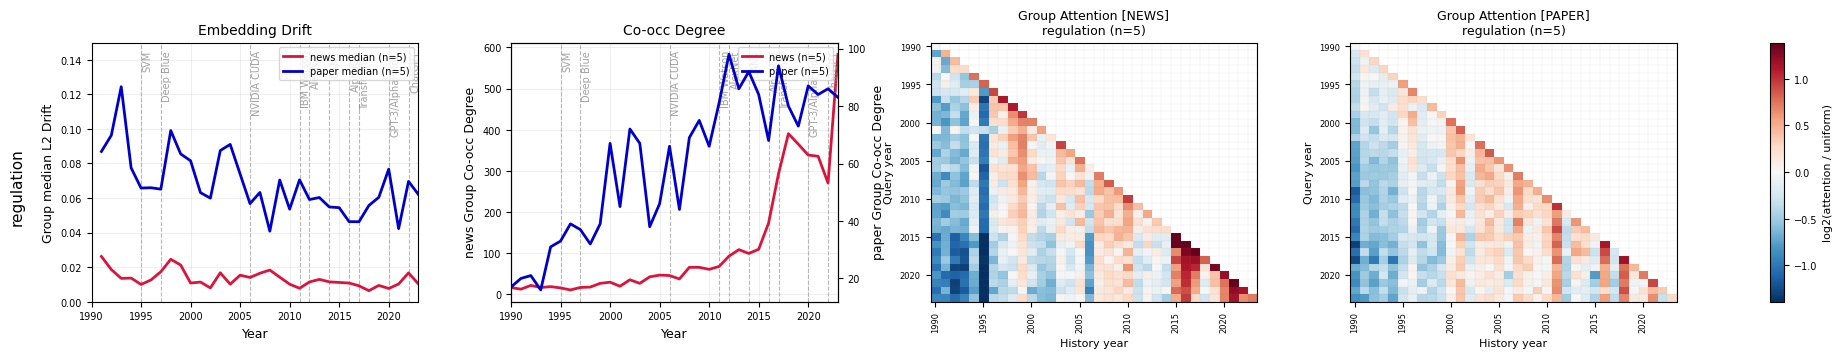


=== accountability ===
'accountability' [news] -> raw=3, usable=3, degree>=100: 2, using=2
  [   183] accountability  news=True paper=True degree=1865
  [ 12069] health insurance portability & accountability act 1996-us  news=True paper=False degree=518
'accountability' [paper] -> raw=3, usable=1, degree>=100: 1, using=1
  [   183] accountability  news=True paper=True degree=7686


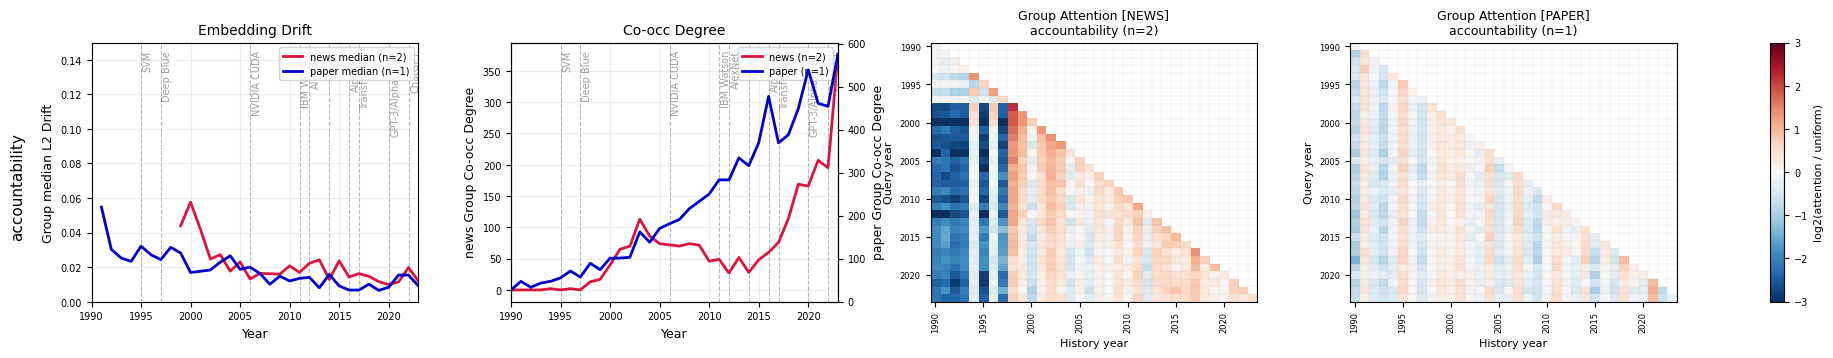


=== risk ===
'risk' [news] -> raw=54, usable=22, degree>=100: 8, using=5
  [ 22790] risk assessment  news=True paper=True degree=1801
  [ 22796] risk management  news=True paper=True degree=1503
  [ 22795] risk factors  news=True paper=False degree=971
  [  6143] credit risk  news=True paper=True degree=583
  [ 12080] health risk assessment  news=True paper=False degree=234
'risk' [paper] -> raw=54, usable=35, degree>=100: 21, using=5
  [ 22796] risk management  news=True paper=True degree=15988
  [ 22790] risk assessment  news=True paper=True degree=12075
  [  6143] credit risk  news=True paper=True degree=3706
  [  8721] empirical risk minimization  news=False paper=True degree=1162
  [ 10081] financial risk  news=False paper=True degree=996


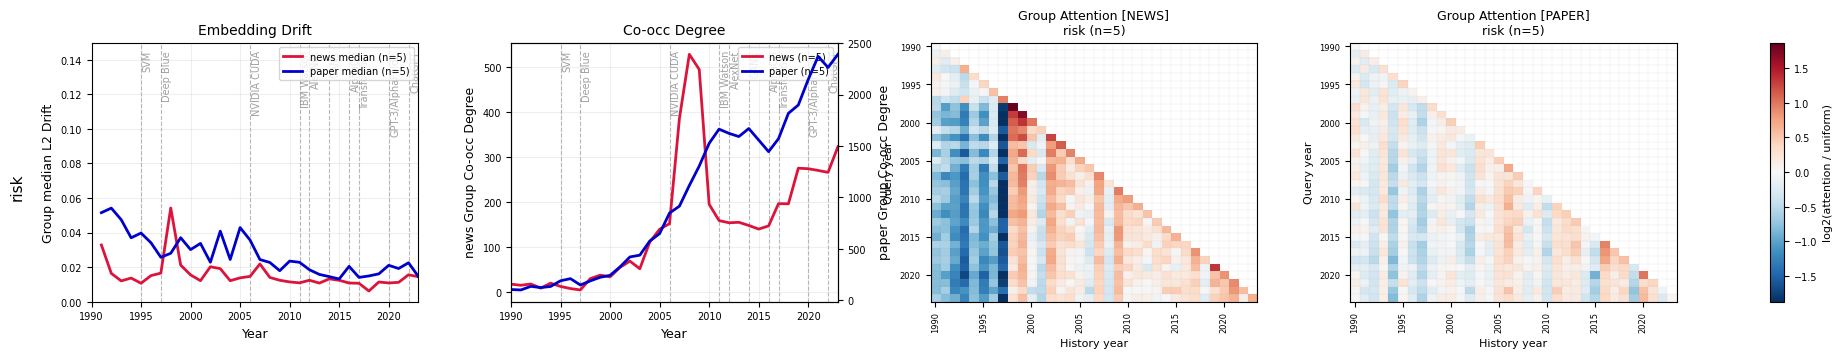


=== safety ===
'safety' [news] -> raw=61, usable=33, degree>=100: 14, using=5
  [ 19380] patient safety  news=True paper=False degree=3281
  [ 21499] public safety  news=True paper=False degree=2414
  [ 27209] traffic accidents & safety  news=True paper=False degree=1984
  [  1850] automobile safety  news=True paper=False degree=1578
  [   655] aircraft accidents & safety  news=True paper=False degree=1457
'safety' [paper] -> raw=61, usable=32, degree>=100: 27, using=5
  [ 18363] occupational safety and health  news=False paper=True degree=4943
  [ 10457] food safety  news=True paper=True degree=2675
  [ 26159] system safety  news=False paper=True degree=1801
  [   298] active safety  news=False paper=True degree=1620
  [ 23068] safety monitoring  news=False paper=True degree=962


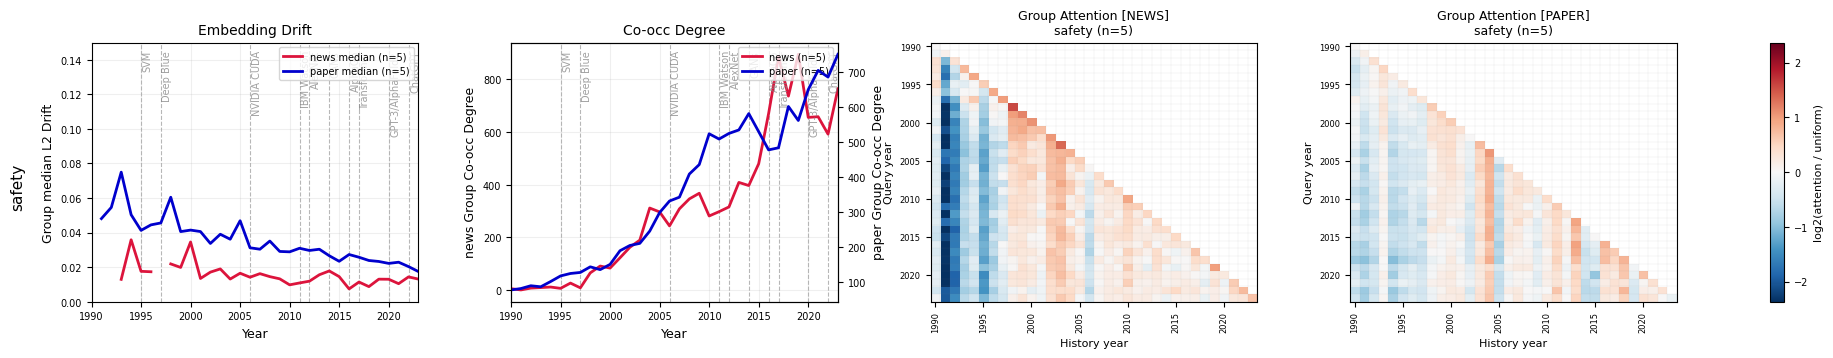


=== politic ===
'politic' [news] -> raw=34, usable=31, degree>=100: 13, using=5
  [ 20381] political campaigns  news=True paper=False degree=1771
  [ 20403] politics  news=True paper=True degree=1681
  [ 20376] political advertising  news=True paper=False degree=970
  [ 20391] political parties  news=True paper=False degree=926
  [ 11279] geopolitics  news=True paper=False degree=321
'politic' [paper] -> raw=34, usable=4, degree>=100: 2, using=2
  [ 20403] politics  news=True paper=True degree=476180
  [  7734] diversity (politics)  news=False paper=True degree=32264


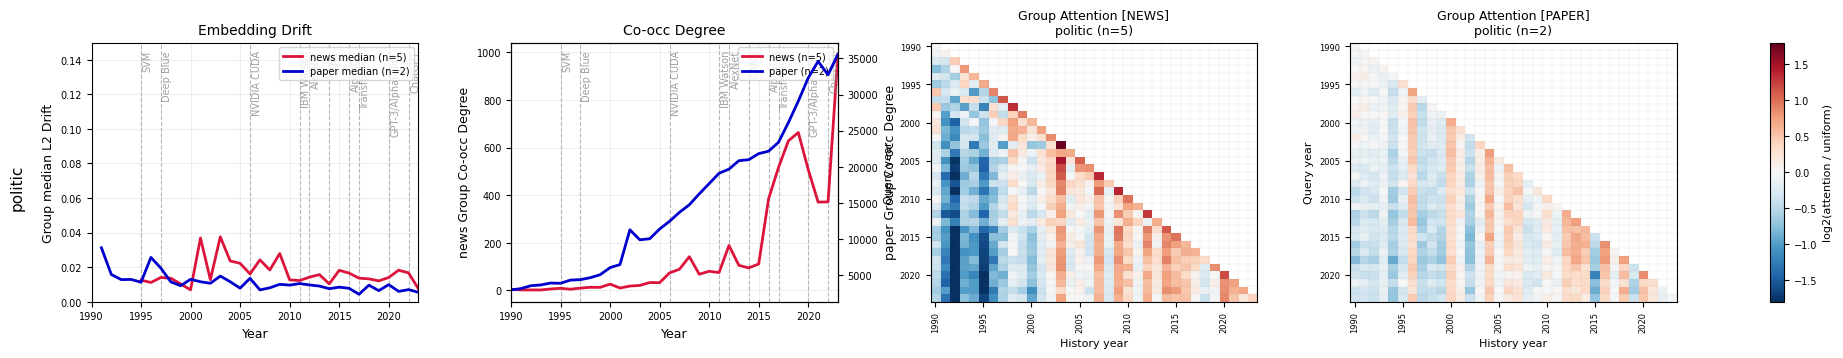


=== ethics ===
'ethics' [news] -> raw=29, usable=12, degree>=100: 3, using=3
  [  9206] ethics  news=True paper=False degree=1827
  [ 21130] professional ethics  news=True paper=True degree=129
  [  3256] business ethics  news=True paper=True degree=110
'ethics' [paper] -> raw=29, usable=24, degree>=100: 18, using=5
  [ 13037] ideal (ethics)  news=False paper=True degree=23892
  [ 24235] situational ethics  news=False paper=True degree=9506
  [  3256] business ethics  news=True paper=True degree=2349
  [  2477] bioethics  news=True paper=True degree=2060
  [ 13464] information ethics  news=True paper=True degree=1578


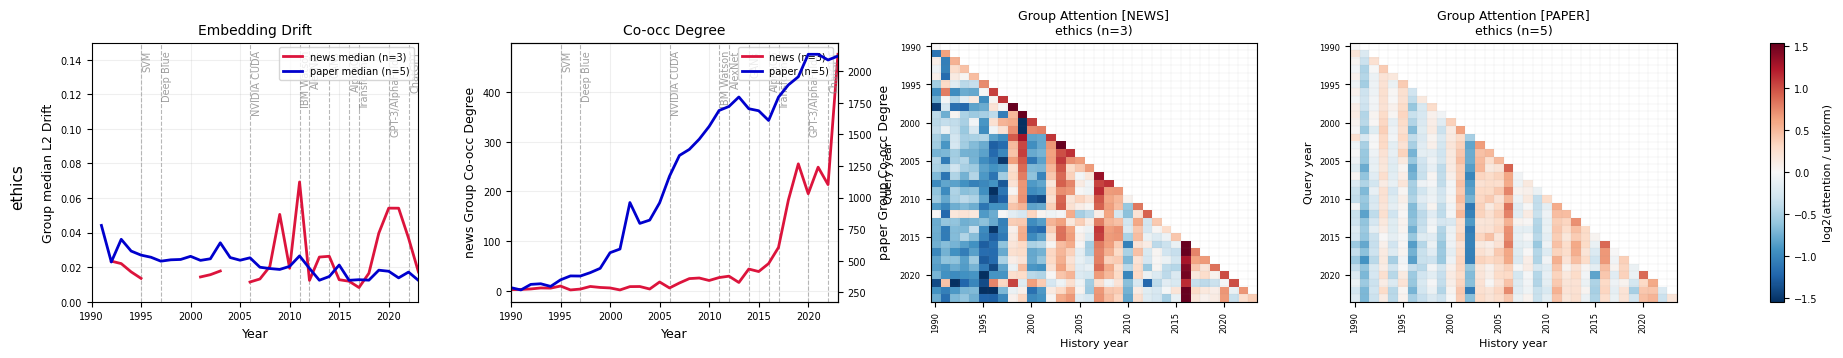


=== bias ===
'bias' [news] -> raw=15, usable=2, degree>=100: 2, using=2
  [  2363] bias  news=True paper=False degree=2002
  [  9822] fear & phobias  news=True paper=False degree=132
'bias' [paper] -> raw=15, usable=13, degree>=100: 9, using=5
  [ 23591] selection bias  news=False paper=True degree=4790
  [ 12395] hindsight bias  news=False paper=True degree=1551
  [  6773] debiasing  news=False paper=True degree=1472
  [ 11111] gender bias  news=False paper=True degree=868
  [  5390] confirmation bias  news=False paper=True degree=419


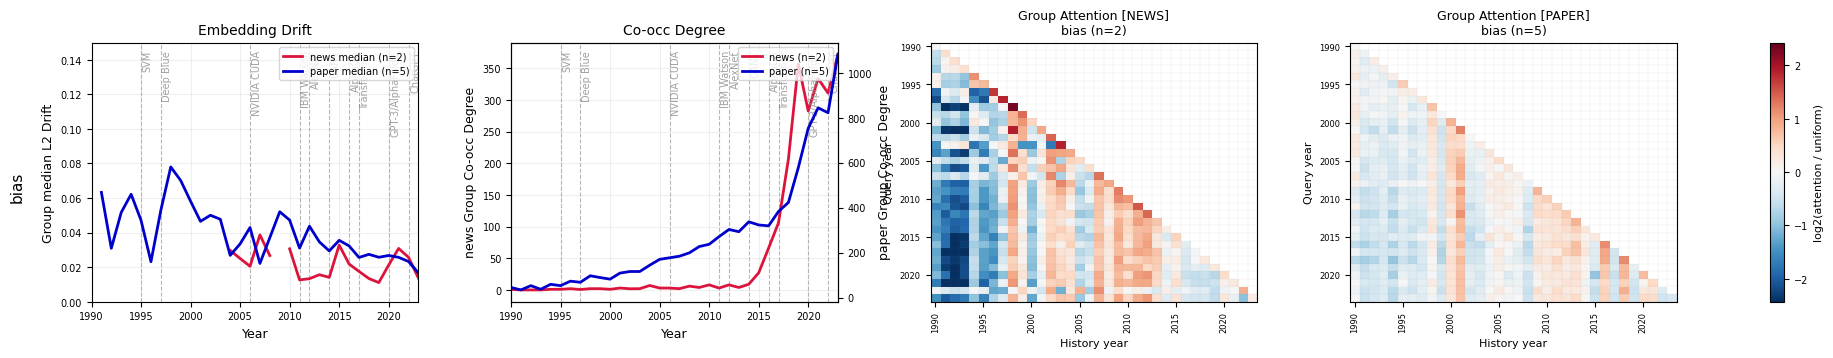


=== surveillance ===
'surveillance' [news] -> raw=9, usable=8, degree>=100: 4, using=4
  [ 26009] surveillance  news=True paper=False degree=5411
  [ 26011] surveillance of citizens  news=True paper=False degree=209
  [ 12088] health surveillance  news=True paper=True degree=183
  [  8572] electronic surveillance  news=True paper=True degree=115
'surveillance' [paper] -> raw=9, usable=3, degree>=100: 2, using=2
  [  8572] electronic surveillance  news=True paper=True degree=127
  [ 12088] health surveillance  news=True paper=True degree=113


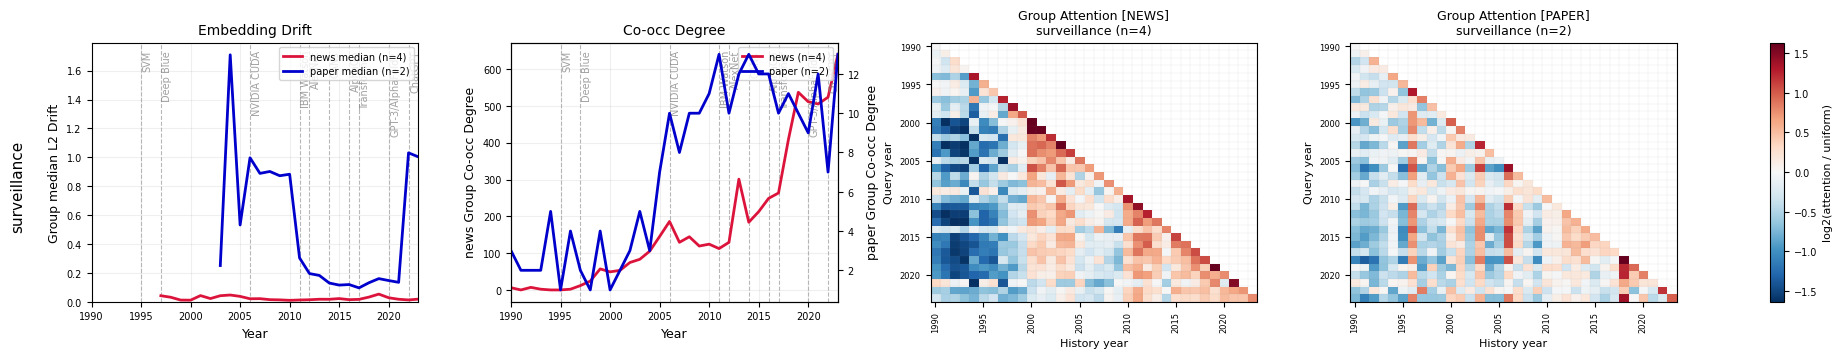


=== cybersecurity ===
'cybersecurity' [news] -> raw=1, usable=1, degree>=100: 1, using=1
  [  6536] cybersecurity  news=True paper=False degree=13814
'cybersecurity' [paper] -> raw=1, usable=0, degree>=100: 0, using=0
[SKIP] paper: no valid paper terms for query 'cybersecurity'


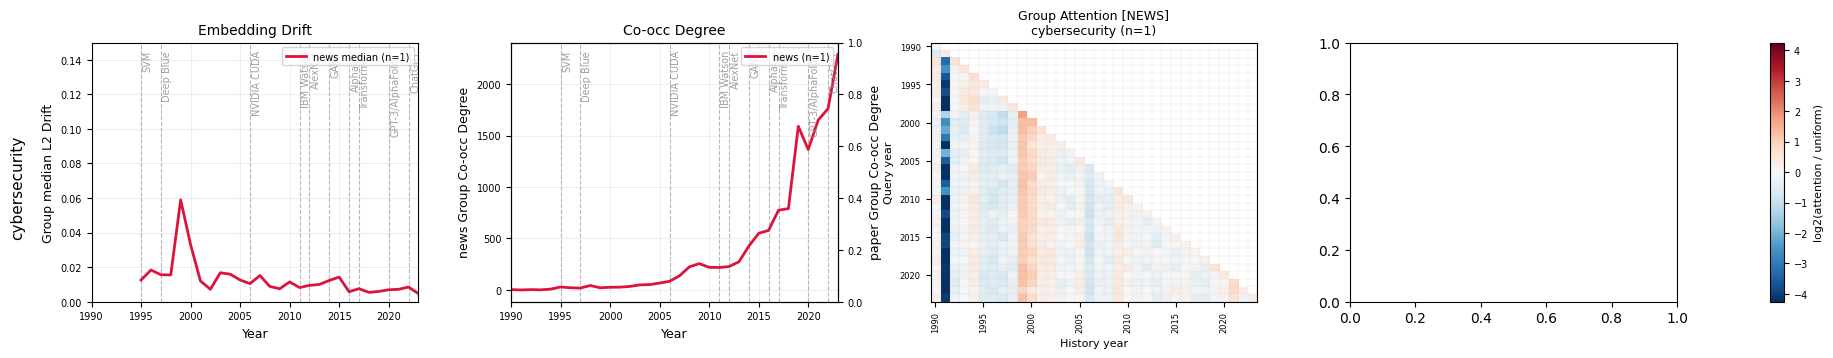


=== human rights ===
'human rights' [news] -> raw=1, usable=1, degree>=100: 1, using=1
  [ 12760] human rights  news=True paper=True degree=897
'human rights' [paper] -> raw=1, usable=1, degree>=100: 1, using=1
  [ 12760] human rights  news=True paper=True degree=9687


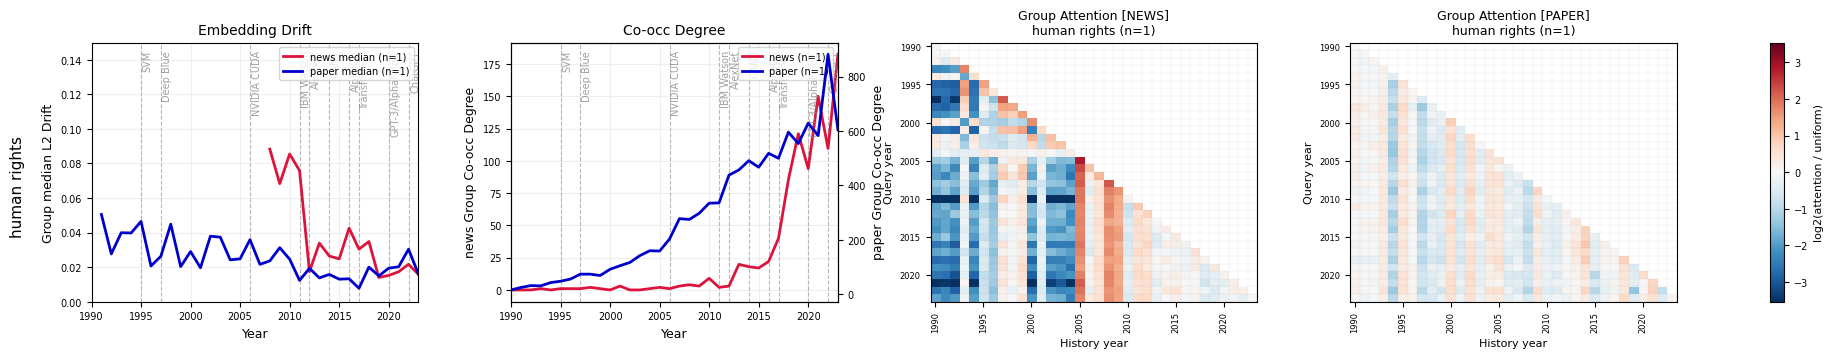


=== trust ===
'trust' [news] -> raw=33, usable=21, degree>=100: 4, using=4
  [ 27582] trust  news=True paper=False degree=1078
  [  1189] antitrust  news=True paper=False degree=799
  [ 27583] trust companies  news=True paper=False degree=241
  [ 27584] trust departments  news=True paper=False degree=143
'trust' [paper] -> raw=33, usable=13, degree>=100: 8, using=5
  [ 27595] trustworthiness  news=True paper=True degree=6780
  [  7714] distrust  news=False paper=True degree=1293
  [ 27588] trust management (information system)  news=False paper=True degree=1181
  [ 27590] trusted computing  news=False paper=True degree=533
  [ 27592] trusted third party  news=False paper=True degree=180


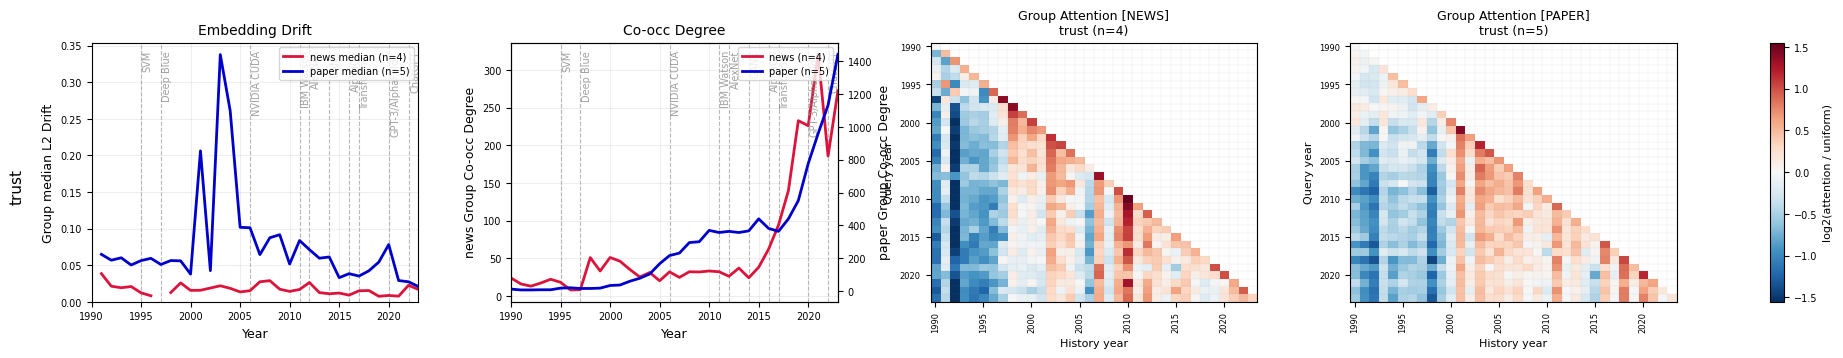


=== labor ===
'labor' [news] -> raw=60, usable=36, degree>=100: 16, using=5
  [  4781] collaboration  news=True paper=True degree=34438
  [ 14537] laboratories  news=True paper=False degree=13087
  [ 14527] labor market  news=True paper=False degree=1232
  [ 16251] medical laboratories  news=True paper=False degree=882
  [ 14532] labor shortages  news=True paper=False degree=772
'labor' [paper] -> raw=60, usable=27, degree>=100: 16, using=5
  [  4784] collaborative learning  news=True paper=True degree=7824
  [  8389] elaboration  news=False paper=True degree=2452
  [  4787] collaborative software  news=False paper=True degree=2342
  [ 28415] virtual laboratory  news=False paper=True degree=1285
  [ 14531] labor relations  news=True paper=True degree=798


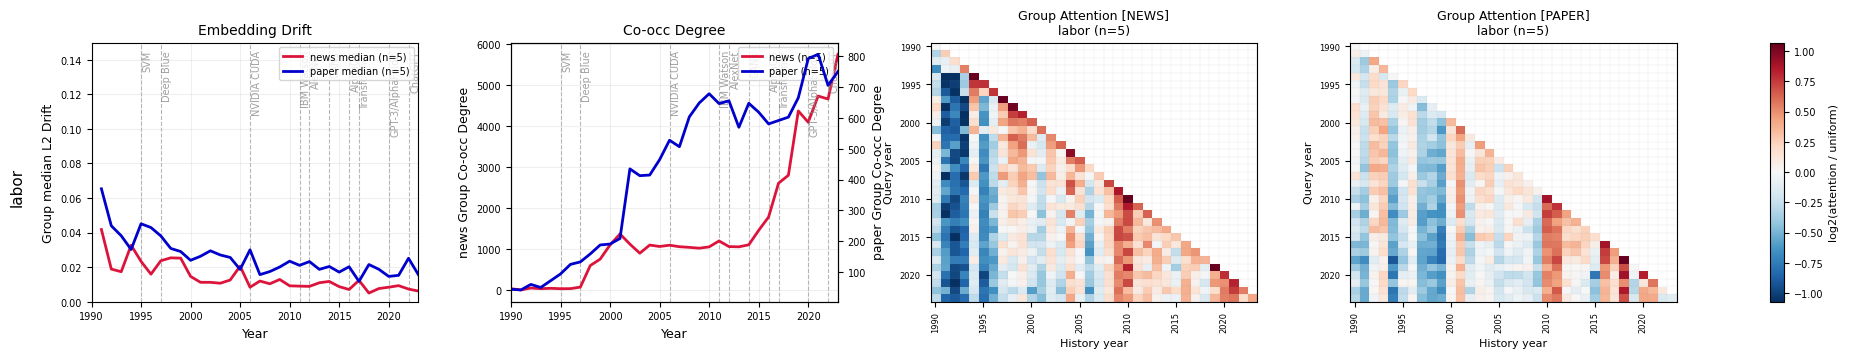


=== workforce ===
'workforce' [news] -> raw=2, usable=2, degree>=100: 2, using=2
  [ 29095] workforce  news=True paper=True degree=7102
  [ 29096] workforce planning  news=True paper=False degree=2549
'workforce' [paper] -> raw=2, usable=1, degree>=100: 1, using=1
  [ 29095] workforce  news=True paper=True degree=7739


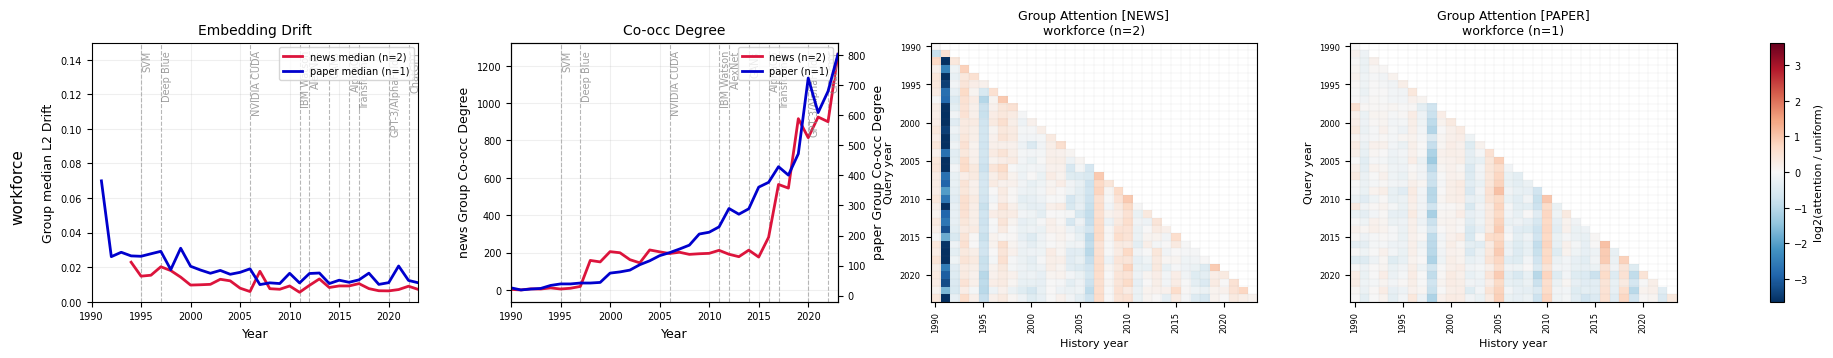


=== algorithm ===
'algorithm' [news] -> raw=46, usable=9, degree>=100: 4, using=4
  [   728] algorithms  news=True paper=False degree=35857
  [  5696] control algorithms  news=True paper=False degree=1549
  [ 18703] optimization algorithms  news=True paper=False degree=293
  [ 11191] genetic algorithms  news=True paper=False degree=225
'algorithm' [paper] -> raw=46, usable=37, degree>=100: 33, using=5
  [ 23590] selection (genetic algorithm)  news=False paper=True degree=475544
  [ 11190] genetic algorithm  news=False paper=True degree=104356
  [  9312] evolutionary algorithm  news=False paper=True degree=35835
  [ 14335] k-nearest neighbors algorithm  news=False paper=True degree=28702
  [  1105] ant colony optimization algorithms  news=False paper=True degree=19773


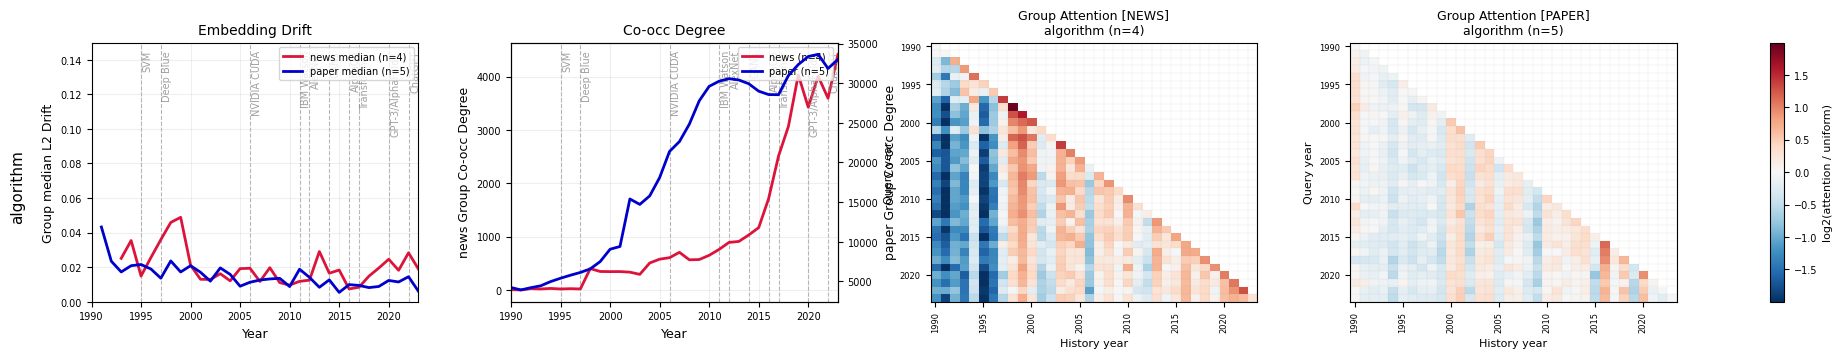


=== deepfake ===
'deepfake' [news] -> raw=0, usable=0, degree>=100: 0, using=0
[SKIP] news: no valid news terms for query 'deepfake'
'deepfake' [paper] -> raw=0, usable=0, degree>=100: 0, using=0
[SKIP] paper: no valid paper terms for query 'deepfake'

=== cloud computing ===
'cloud computing' [news] -> raw=1, usable=1, degree>=100: 1, using=1
  [  4615] cloud computing  news=True paper=True degree=7726
'cloud computing' [paper] -> raw=1, usable=1, degree>=100: 1, using=1
  [  4615] cloud computing  news=True paper=True degree=76053


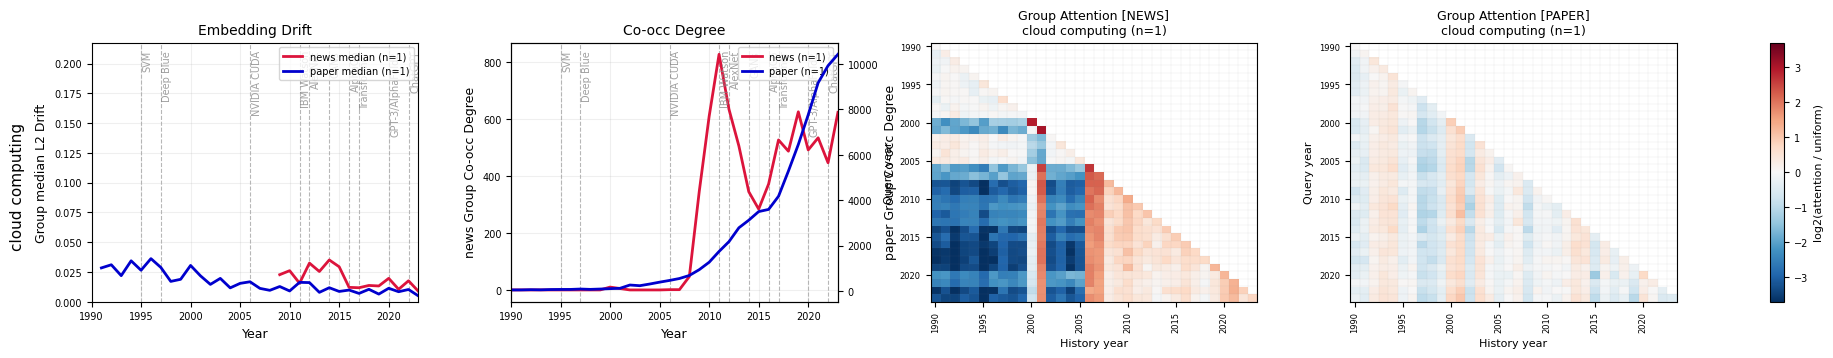


=== semiconductor ===
'semiconductor' [news] -> raw=7, usable=2, degree>=100: 2, using=2
  [ 23698] semiconductors  news=True paper=False degree=9673
  [ 23697] semiconductor research  news=True paper=False degree=215
'semiconductor' [paper] -> raw=7, usable=5, degree>=100: 5, using=5
  [ 23694] semiconductor  news=False paper=True degree=6674
  [ 23696] semiconductor memory  news=False paper=True degree=2219
  [ 23695] semiconductor industry  news=False paper=True degree=694
  [ 28922] wide-bandgap semiconductor  news=False paper=True degree=401
  [ 18785] organic semiconductor  news=False paper=True degree=266


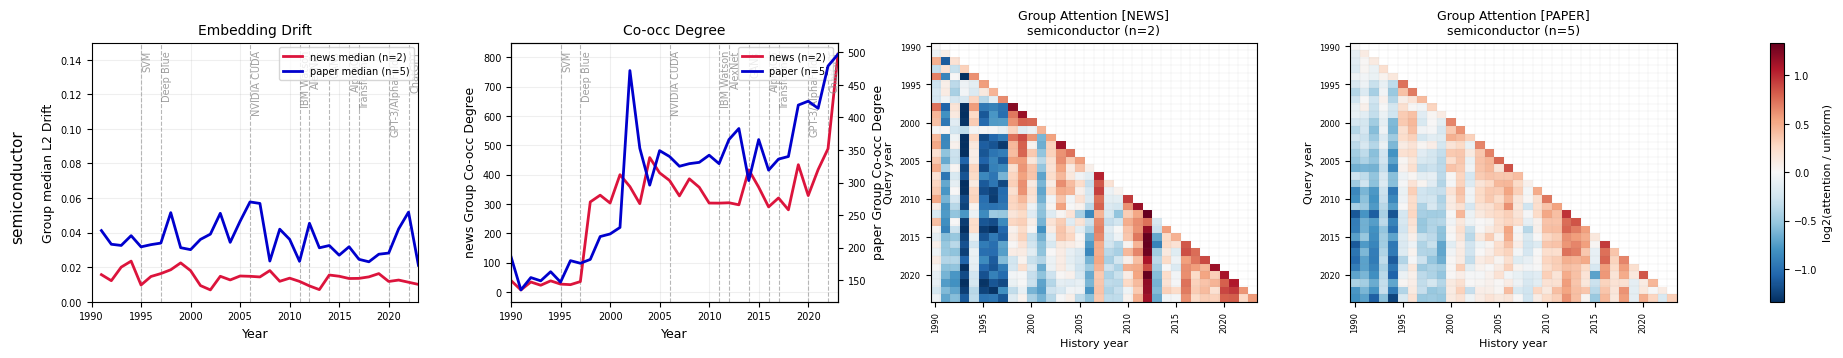


=== venture capital ===
'venture capital' [news] -> raw=2, usable=2, degree>=100: 2, using=2
  [ 28253] venture capital  news=True paper=True degree=4171
  [ 28254] venture capital companies  news=True paper=False degree=1094
'venture capital' [paper] -> raw=2, usable=1, degree>=100: 1, using=1
  [ 28253] venture capital  news=True paper=True degree=1564


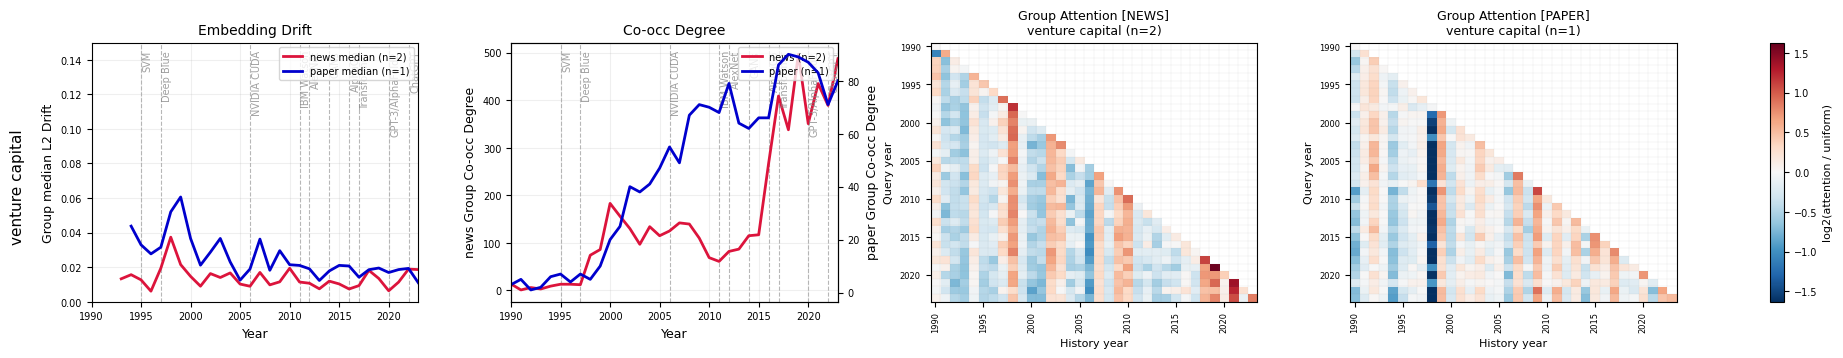


=== data ===
'data' [news] -> raw=200, usable=55, degree>=100: 31, using=5
  [  6679] data mining  news=True paper=False degree=9469
  [  6698] data science  news=True paper=False degree=8672
  [  2387] big data  news=True paper=True degree=7141
  [  6640] data analysis  news=True paper=True degree=6247
  [  6671] data integrity  news=True paper=True degree=4571
'data' [paper] -> raw=200, usable=167, degree>=100: 149, using=5
  [ 23838] set (abstract data type)  news=False paper=True degree=625252
  [  8898] enhanced data rates for gsm evolution  news=False paper=True degree=111765
  [ 16142] measure (data warehouse)  news=False paper=True degree=111036
  [ 22333] relation (database)  news=False paper=True degree=79415
  [  6701] data set  news=False paper=True degree=73250


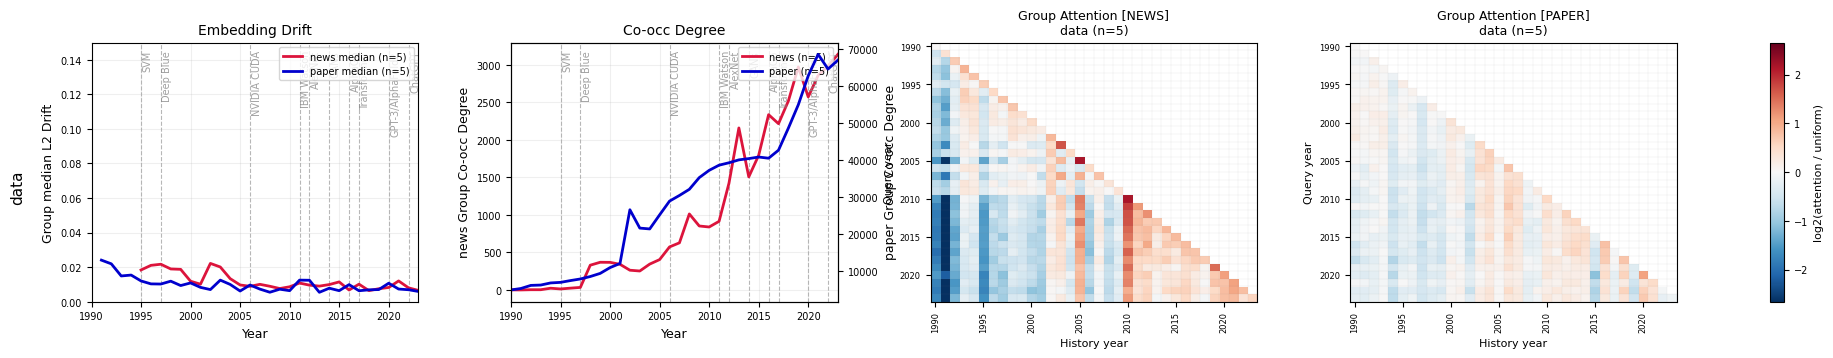

In [61]:
AI_ST_PROBES = {
    "technical_capability_and_knowledge": [
        "artificial intelligence",
        "machine learning",
        "deep learning",
        "neural network",
        "automation",
    ],
    "application_and_user_practices": [
        "health care",
        "education",
        "employment",
        "productivity",
        "industr",
        "creativ",
        "arts",
        "automobile",
        "pharmaceut"
    ],
    "governance_policy_and_institutional_control": [
        "privacy",
        "regulation",
        "accountability",
        "risk",
        "safety",
        "politic"
    ],
    "cultural_meaning_and_social_concern": [
        "ethics",
        "bias",
        "surveillance",
        "cybersecurity",
        "human rights",
        "trust",
        "labor",
        'workforce',
        "algorithm",
        "deepfake"
    ],
    "material_and_industrial_infrastructure": [
        "cloud computing",
        "semiconductor",
        "venture capital",
        "data",
        
    ],
}

CASE_GROUP_SEEDS_GEELS = [
    seed
    for domain, seeds in AI_ST_PROBES.items()
    for seed in seeds
]

for seed in CASE_GROUP_SEEDS_GEELS:
    print(f"\n=== {seed} ===")
    plot_group_drift_vs_cooc_case({'news': seed, 'paper': seed}, top_k=5,  min_degree=100, save=True)